# Lecture 9 — Pattern formation with local interactions.

In [51]:
# Housekeeping code...
from pathlib import Path
import base64
import io

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch, Rectangle, Circle
from scipy.sparse import coo_matrix
from scipy.sparse.csgraph import connected_components
from scipy import ndimage
from IPython.display import display, HTML, Video

ROOT = Path('..') if Path('../media').exists() else Path('.')
if not (ROOT/'media').exists():
    raise FileNotFoundError('Run this notebook from the course repository.')
MEDIA = ROOT/'media'
DATA = ROOT/'data'

BLUE = '#3B6FB6'; ORANGE = '#D97706'; GOLD = '#C9A227'
PINK = '#B64E77'; OLIVE = '#718355'; INK = '#263238'
GREY = '#9AA0A6'; LIGHT = '#E7EAED'
SPIN_MAP = ListedColormap([ORANGE, BLUE])
TC = 2/np.log(1 + np.sqrt(2))
plt.rcParams.update({
    'figure.dpi': 120, 'figure.figsize': (9, 4.6),
    'axes.spines.top': False, 'axes.spines.right': False,
    'font.size': 13, 'axes.labelsize': 14, 'legend.fontsize': 11,
    'text.color': INK, 'axes.labelcolor': INK,
    'xtick.color': INK, 'ytick.color': INK,
    'axes.prop_cycle': plt.cycler(color=[BLUE, ORANGE, PINK, OLIVE, GOLD]),
})

def movie(filename, width=720):
    return Video(url=str(MEDIA/filename), width=width,
                 html_attributes='controls loop muted playsinline')

def show_widget(widget, image_bytes):
    # Live notebook frontends use the widget; static viewers have a PNG fallback.
    display({'application/vnd.jupyter.widget-view+json': {
                 'version_major': 2, 'version_minor': 0, 'model_id': widget.model_id},
             'image/png': base64.b64encode(image_bytes).decode(),
             'text/plain': 'Interactive demonstration'}, raw=True)

# Lattice display, equilibrium sampling, and local updates.
def spin_image(ax, spins, label=None):
    ax.imshow(spins, cmap=SPIN_MAP, vmin=-1, vmax=1, interpolation='nearest', origin='lower')
    ax.set_xticks([]); ax.set_yticks([])
    if label is not None:
        ax.set_xlabel(label)

def periodic_edges(side):
    sites = np.arange(side*side).reshape(side, side)
    return np.tile(sites.ravel(), 2), np.concatenate([
        np.roll(sites, -1, axis=0).ravel(), np.roll(sites, -1, axis=1).ravel()])

def components(site_count, source, target):
    graph = coo_matrix((np.ones(len(source)), (source, target)),
                       shape=(site_count, site_count)).tocsr()
    return connected_components(graph, directed=False)

def sw_step(spins, temperature, rng, edges=None):
    """Cluster update for equilibrium sampling only; not physical time."""
    a, b = periodic_edges(spins.shape[0]) if edges is None else edges
    flat = spins.ravel()
    occupied = (flat[a] == flat[b]) & (rng.random(len(a)) < -np.expm1(-2/temperature))
    count, labels = components(flat.size, a[occupied], b[occupied])
    colors = rng.choice(np.array([-1, 1], dtype=np.int8), size=count)
    return colors[labels].reshape(spins.shape)

def energy_per_site(spins):
    return -np.mean(spins * (np.roll(spins, -1, axis=0) + np.roll(spins, -1, axis=1)))

def heatbath_sweep(spins, temperature, field, rng, uniforms=None):
    """Local checkerboard heat-bath sweep; accepts one lattice or a batch of lattices.

    Even periodic side lengths ensure no neighbors are updated simultaneously.
    Temperature and field are in units J/k_B and J; every site is updated once.
    """
    side = spins.shape[-1]
    if side % 2:
        raise ValueError('Checkerboard updates require an even periodic lattice.')
    yy, xx = np.indices((side, side))
    for parity in [0, 1]:
        neighbors = sum(np.roll(spins, shift, axis=axis)
                        for axis in [-2, -1] for shift in [-1, 1])
        probability_plus = 1 / (1 + np.exp(-2*(neighbors + field)/temperature))
        random_values = rng.random(spins.shape) if uniforms is None else uniforms[parity]
        proposal = np.where(random_values < probability_plus, 1, -1)
        mask = ((xx + yy) % 2 == parity)
        spins[..., mask] = proposal[..., mask]
    return spins



def sample_lattices(side, temperature, *, draws=256, burn=192, seed=900):
    edges = periodic_edges(side)
    saved = []
    for chain in range(2):
        rng = np.random.default_rng(seed + chain)
        state = (rng.choice([-1, 1], size=(side, side)) if chain == 0
                 else np.ones((side, side))).astype(np.int8)
        for _ in range(burn): state = sw_step(state, temperature, rng, edges)
        snapshots = []
        for _ in range(draws):
            state = sw_step(state, temperature, rng, edges)
            snapshots.append(state.copy())
        saved.append(np.asarray(snapshots))
    return np.asarray(saved)

## Lipid domains/rafts when you cool a membrane

Veatch et al. (2008), [*Critical Fluctuations in Plasma Membrane Vesicles*](https://doi.org/10.1021/cb800012x), [Movie S1](https://acs.figshare.com/articles/media/Critical_Fluctuations_in_Plasma_Membrane_Vesicles/2938459).


In [52]:
movie('membranes/gpmv-critical-cooling-reheating.mp4')

### An oily sheet in water

A phospholipid has a hydrophilic **head** and (usually) two hydrophobic **tails**.


![Phospholipid structure and a membrane cutaway showing two leaflets, the hydrophobic core, cholesterol, and a membrane protein.](../media/membranes/membrane-molecular-cutaway.png)


### Membrane shape and lipid interactions depend on shape and chemistry

![Molecular shape controls curvature; cis kinks change tail packing; ions screen repulsion between charged heads.](../media/membranes/membrane-shape-packing-charge.png)

Tail contacts, headgroup hydration, and hydrogen bonding all contribute to the cost of exchanging neighbors.

We will start by modelling the membrane as a 2D Ising model, with two lipid species that correspond to our $\uparrow$ and $\downarrow$ spins from last time.


## From a chain to a sheet

In the 1D Ising model, reversing a spin or blocks of spins creates **two domain walls**.

In a sheet, reversing a patch creates a **boundary**.

Each broken neighbor bond still costs $2J$ work of energy.

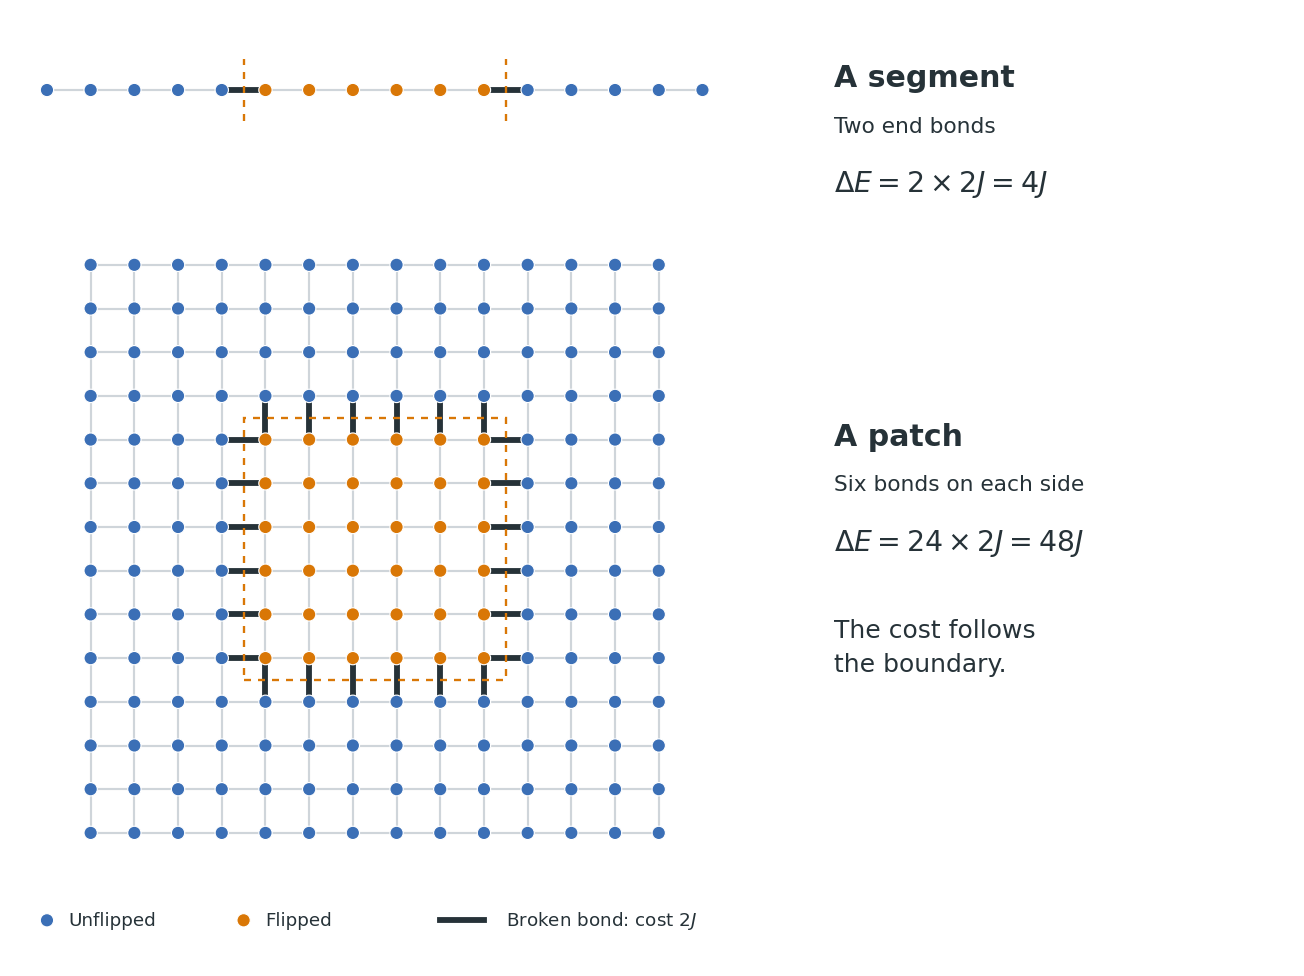

In [53]:
from matplotlib.collections import LineCollection

# One coordinate system keeps sites and bond lengths identical in 1D and 2D.
fig, ax = plt.subplots(figsize=(11, 8.2), facecolor='white')
ax.set_aspect('equal')

chain = np.ones((1, 16), dtype=int)
chain[0, 5:11] = -1
sheet = np.ones((14, 14), dtype=int)
sheet[4:10, 4:10] = -1

def draw_domain_lattice(states, offset):
    yy, xx = np.indices(states.shape)
    points = np.column_stack([xx.ravel(), yy.ravel()]) + offset
    ordinary, broken = [], []
    for y, x in np.ndindex(states.shape):
        for dy, dx in [(0, 1), (1, 0)]:
            if y + dy < states.shape[0] and x + dx < states.shape[1]:
                bond = [(x + offset[0], y + offset[1]),
                        (x + dx + offset[0], y + dy + offset[1])]
                (ordinary if states[y, x] == states[y + dy, x + dx]
                 else broken).append(bond)
    ax.add_collection(LineCollection(ordinary, colors='#CFD5DA', linewidths=1.3, zorder=1))
    ax.add_collection(LineCollection(broken, colors=INK, linewidths=3.5, zorder=2))
    ax.scatter(points[:, 0], points[:, 1], s=64,
               c=np.where(states.ravel() == 1, BLUE, ORANGE),
               edgecolors='white', linewidths=.7, zorder=3)
    return len(broken)

chain_broken = draw_domain_lattice(chain, (0, 17))
sheet_broken = draw_domain_lattice(sheet, (1, 0))
assert (chain_broken, sheet_broken) == (2, 24)

# The dashed boundary crosses precisely the unlike-neighbor bonds.
for x in [4.5, 10.5]:
    ax.plot([x, x], [16.3, 17.7], color=ORANGE, lw=1.4, ls=(0, (3, 3)))
ax.add_patch(Rectangle((4.5, 3.5), 6, 6, fill=False,
                       edgecolor=ORANGE, lw=1.4, linestyle=(0, (3, 3)), zorder=2))

ax.text(18, 17.6, 'A segment', fontsize=18, weight='bold', va='top')
ax.text(18, 16.4, 'Two end bonds', fontsize=13, va='top')
ax.text(18, 15.2, r'$\Delta E = 2\times 2J = 4J$', fontsize=17, va='top')
ax.text(18, 9.4, 'A patch', fontsize=18, weight='bold', va='top')
ax.text(18, 8.2, 'Six bonds on each side', fontsize=13, va='top')
ax.text(18, 7.0, r'$\Delta E = 24\times 2J = 48J$', fontsize=17, va='top')
ax.text(18, 4.9, 'The cost follows\nthe boundary.', fontsize=15, va='top', linespacing=1.5)

# A compact key; colors denote the two spin states, not different site sizes.
ax.scatter([0, 4.5], [-2, -2], s=64, c=[BLUE, ORANGE], edgecolors='white', linewidths=.7)
ax.text(.5, -2, 'Unflipped', va='center', fontsize=11)
ax.text(5, -2, 'Flipped', va='center', fontsize=11)
ax.plot([9, 10], [-2, -2], color=INK, lw=3.5)
ax.text(10.5, -2, r'Broken bond: cost $2J$', va='center', fontsize=11)
ax.set(xlim=(-.8, 28.5), ylim=(-3, 18.8))
ax.set_axis_off()
fig.subplots_adjust(left=.02, right=.99, bottom=.02, top=.99)
plt.show()


### An external field favors one state

The applied field $h$ adds energy $-h s_i$ at each site.

| Applied bias | Favored state |
| --- | --- |
| $h>0$ | $s_i=+1$ |
| $h=0$ | Neither sign |
| $h<0$ | $s_i=-1$ |

For magnetic spins, $h$ is the magnetic field times the spin's magnetic moment: it has **units of energy**. For a lipid mixture, the analogous bias is a chemical preference for one species.

Setting $h=0$ isolates spontaneous ordering; applying a small $h$ measures the response to an imposed bias.


### The 2D Ising model

One binary state at each site, $s_i=\pm1$.

$$
E(\mathbf s)=-J\sum_{\langle ij\rangle}s_i s_j-h\sum_i s_i,
\qquad J>0.
$$

The **external field** $h$ biases every spin: $h>0$ favors $+1$, while $h<0$ favors $-1$.

Reversing one spin changes the energy by:

$$
\Delta E=2s_i\left(J\sum_{j\in\mathrm{nn}(i)}s_j+h\right).
$$

Only its four neighbors and the field enter the sum.

### Local alignment competes with thermal noise

The **local effective field** combines neighboring spins and the applied bias:

$$
h_i^{\mathrm{eff}}=\underbrace{J\sum_{j\in\mathrm{nn}(i)}s_j}_{\text{neighbors}}+\underbrace{h}_{\text{applied bias}}.
$$

To simulate this model, we can use **heat-bath updates**: with its neighbors held fixed, each spin is sampled from its local thermal equilibrium distribution and assigned $+1$ with probability:

$$
p(s_i=+1\mid\text{neighbors})=\frac{1}{1+e^{-2\beta h_i^{\mathrm{eff}}}},
\qquad \beta=\frac1{k_BT}.
$$

Low temperature favors the sign of $h_i^{\mathrm{eff}}$; high temperature randomizes the spins.

### 2D Ising model simulation with periodic boundary conditions

Recall: 
$$
m=\frac1N\sum_i s_i,\qquad N=L^2.
$$

At zero applied field, the **critical temperature** $T_c$ separates spontaneous ordering below $T_c$ from disorder above it. For the infinite square lattice, $k_BT_c/J\simeq2.269$.


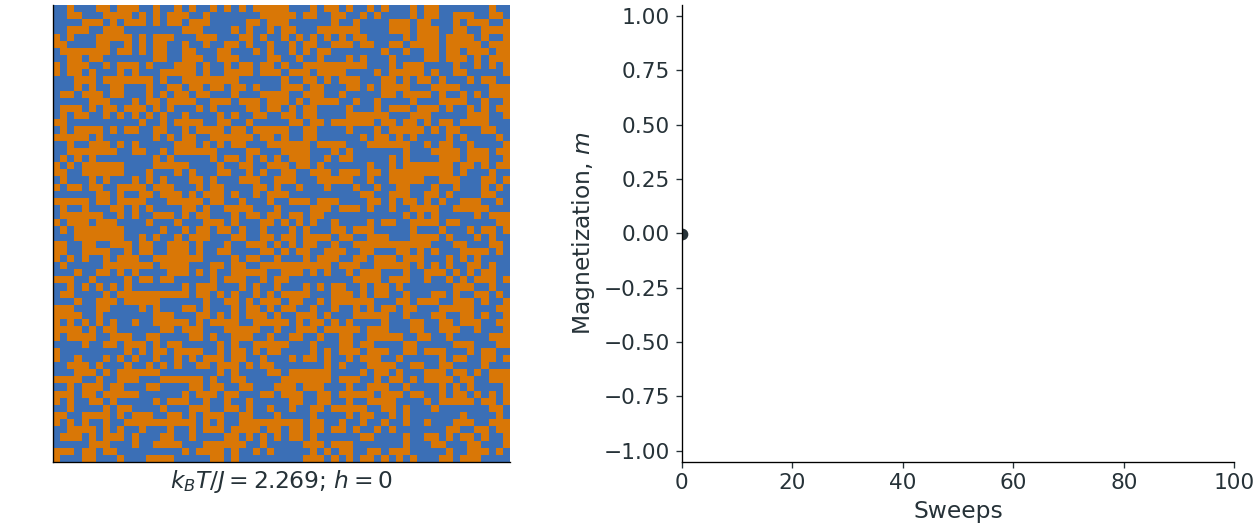

In [54]:
# Run this cell to activate the controls. Temperature and field changes keep the current spins.
import asyncio
import io
import ipywidgets as widgets
from PIL import Image
from matplotlib.figure import Figure
from matplotlib.backends.backend_agg import FigureCanvasAgg

class IsingDemo:
    def __init__(self, seed=567):
        self.seed = seed
        self.task = None
        self.closed = False
        style = {'description_width': '105px'}
        layout = widgets.Layout(width='370px')
        self.temperature = widgets.FloatSlider(value=2.269185314, min=0.25, max=5,
            step=0.05, description='kᵦT / J', readout_format='.2f',
            continuous_update=False, style=style, layout=layout)
        self.field = widgets.FloatSlider(value=0, min=-0.5, max=0.5, step=0.01,
            description='h / J', readout_format='.2f', continuous_update=False,
            style=style, layout=layout)
        self.side = widgets.SelectionSlider(options=[16, 32, 48, 64, 96, 128], value=64,
            description='Side length, L', continuous_update=False, style=style, layout=layout)
        self.speed = widgets.IntSlider(value=4, min=1, max=20, description='Sweeps/frame',
            continuous_update=False, style=style, layout=layout)
        self.initial = widgets.Dropdown(options=['Random', 'All up', 'All down', 'Two domains'],
            value='Random', description='Reset state', style=style, layout=layout)
        self.run = widgets.ToggleButton(value=False, description='Run', icon='play')
        self.step = widgets.Button(description='1 sweep', icon='step-forward')
        self.reset_button = widgets.Button(description='Reset', icon='refresh')
        self.critical = widgets.Button(description='T = Tc; h = 0')
        self.lattice_image = widgets.Image(format='png', layout=widgets.Layout(width='480px', height='480px'))
        self.history_image = widgets.Image(format='png', layout=widgets.Layout(width='460px'))
        self.status = widgets.HTML()
        self.legend = widgets.HTML('<span style="color:#3B6FB6">■ ↑</span>&nbsp;&nbsp;'
                                  '<span style="color:#D97706">■ ↓</span>&nbsp;&nbsp;Periodic boundaries')
        self.history_figure = Figure(figsize=(4.8, 3.8), dpi=110, layout='constrained')
        self.canvas = FigureCanvasAgg(self.history_figure)
        self.ax = self.history_figure.subplots()
        self.ax.set(xlabel='Sweeps', ylabel='Magnetization, m', ylim=(-1.05, 1.05))
        self.ax.axhline(0, color=GREY, lw=1)
        self.line, = self.ax.plot([], [], color=INK, lw=1.7)
        controls = widgets.VBox([self.temperature, self.field, self.side, self.speed, self.initial])
        buttons = widgets.HBox([self.run, self.step, self.reset_button, self.critical],
                              layout=widgets.Layout(flex_flow='row wrap'))
        plots = widgets.HBox([self.lattice_image, widgets.VBox([self.status, self.history_image])],
                            layout=widgets.Layout(flex_flow='row wrap', align_items='center'))
        self.ui = widgets.VBox([controls, buttons, self.legend, plots])
        self.run.observe(self._toggle, names='value')
        self.step.on_click(lambda _: self.advance(1))
        self.reset_button.on_click(lambda _: self.reset())
        self.critical.on_click(self._critical)
        self.side.observe(lambda _: self.reset(), names='value')
        self.temperature.observe(lambda _: self.render(), names='value')
        self.field.observe(lambda _: self.render(), names='value')
        self.reset()

    def reset(self):
        self.run.value = False
        self.rng = np.random.default_rng(self.seed)
        L = self.side.value
        if self.initial.value == 'Random':
            self.spins = self.rng.choice([-1, 1], size=(L, L)).astype(np.int8)
        elif self.initial.value == 'Two domains':
            self.spins = np.ones((L, L), dtype=np.int8)
            self.spins[:, :L//2] = -1
        else:
            self.spins = np.full((L, L), 1 if self.initial.value == 'All up' else -1, dtype=np.int8)
        self.sweeps = 0
        self.history = [(0, self.spins.mean())]
        self.render()

    def _critical(self, _):
        self.temperature.value = TC
        self.field.value = 0

    def advance(self, sweeps):
        for _ in range(sweeps):
            heatbath_sweep(self.spins, self.temperature.value, self.field.value, self.rng)
            self.sweeps += 1
            self.history.append((self.sweeps, self.spins.mean()))
        self.history = self.history[-2000:]
        self.render()

    def render(self):
        if not hasattr(self, 'spins') or self.closed:
            return
        colors = np.array([[217, 119, 6], [59, 111, 182]], dtype=np.uint8)
        rgb = colors[(self.spins > 0).astype(int)]
        image = Image.fromarray(rgb).resize((480, 480), Image.Resampling.NEAREST)
        buffer = io.BytesIO(); image.save(buffer, format='PNG')
        self.lattice_image.value = buffer.getvalue()
        data = np.asarray(self.history)
        self.line.set_data(data[:, 0], data[:, 1])
        self.ax.set_xlim(max(0, data[0, 0]), max(100, self.sweeps))
        buffer = io.BytesIO(); self.canvas.print_png(buffer)
        self.history_image.value = buffer.getvalue()
        m = self.spins.mean()
        e = energy_per_site(self.spins) - self.field.value*m
        self.status.value = (f'<b>{self.side.value} × {self.side.value} spins</b><br>'
            f'Sweeps: {self.sweeps:,} &nbsp; m = {m:+.3f}<br>'
            f'E / (NJ) = {e:.3f} &nbsp; T / Tc = {self.temperature.value/TC:.3f}')

    def _toggle(self, change):
        if change['new']:
            self.run.description = 'Pause'; self.run.icon = 'pause'
            self.step.disabled = True
            self.task = asyncio.get_running_loop().create_task(self._animate())
        else:
            self.run.description = 'Run'; self.run.icon = 'play'
            self.step.disabled = False
            if self.task is not None:
                self.task.cancel(); self.task = None

    async def _animate(self):
        try:
            while self.run.value and not self.closed:
                self.advance(self.speed.value)
                await asyncio.sleep(0.08)
        except asyncio.CancelledError:
            pass
        except Exception as error:
            self.run.value = False
            self.status.value = f'<b>Simulation stopped:</b> {error}'
            raise

    def close(self):
        self.run.value = False
        self.closed = True
        for widget in [self.ui, self.temperature, self.field, self.side, self.speed,
                       self.initial, self.run, self.step, self.reset_button,
                       self.critical, self.lattice_image, self.history_image,
                       self.status, self.legend]:
            widget.close()
        self.history_figure.clear()

# Rerunning this cell stops and closes the previous copy.
if 'ising_demo' in globals():
    ising_demo.close()
ising_demo = IsingDemo()

_snapshot = Figure(figsize=(10.5, 4.4), layout='constrained')
_canvas = FigureCanvasAgg(_snapshot); _axes = _snapshot.subplots(1, 2)
spin_image(_axes[0], ising_demo.spins, r'$k_BT/J=2.269$; $h=0$')
_axes[1].plot([0], [ising_demo.spins.mean()], 'o', color=INK)
_axes[1].set(xlabel='Sweeps', ylabel='Magnetization, $m$', ylim=(-1.05, 1.05), xlim=(0, 100))
_buffer = io.BytesIO(); _canvas.print_png(_buffer)
show_widget(ising_demo.ui, _buffer.getvalue())
_snapshot.clear()

We can look at the distribution of $m$ for 192 simulations run to *equilibrium* at different temperatures:

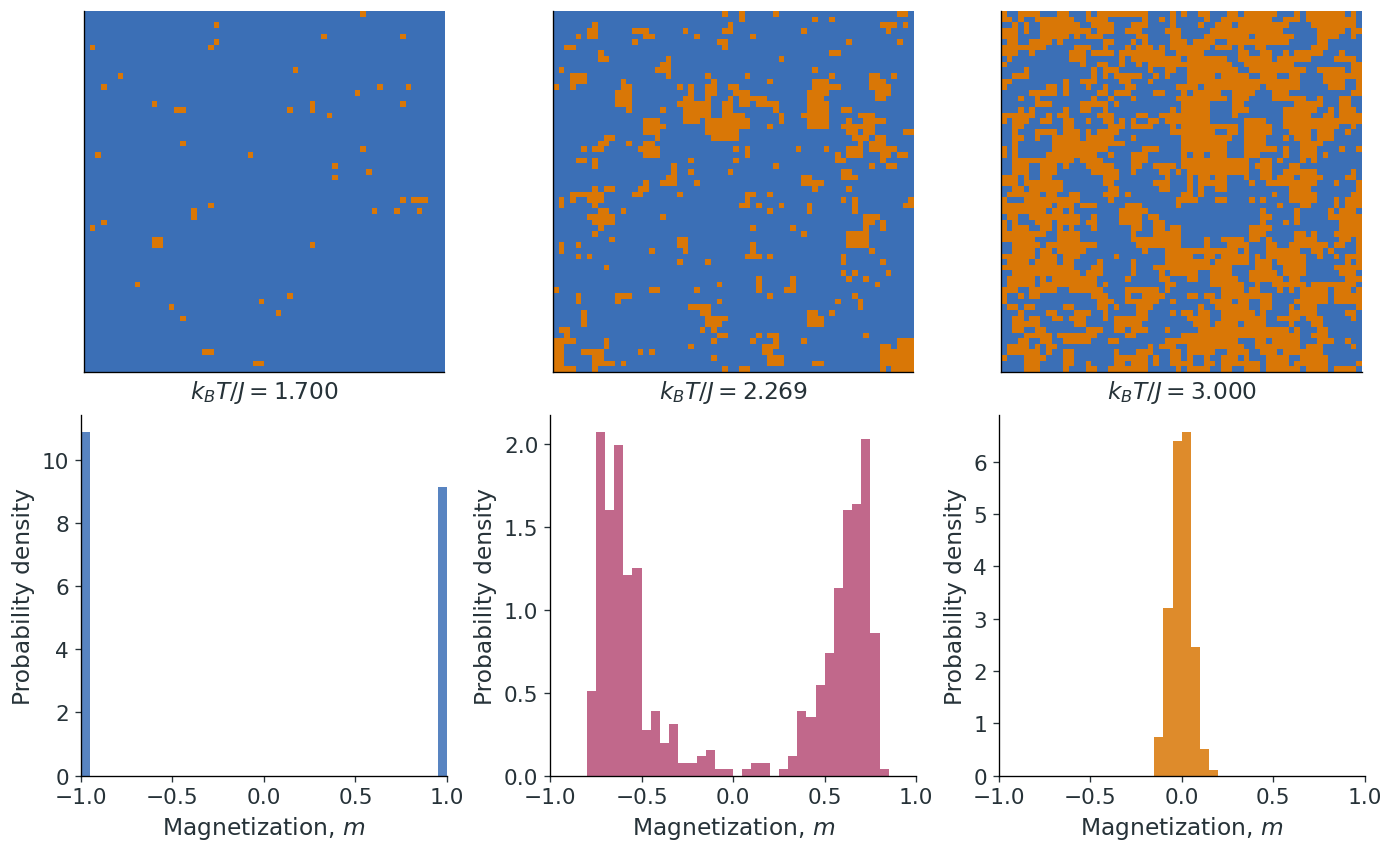

In [55]:
model_samples = {}
for ti, temperature in enumerate([1.7, TC, 3.0]):
    model_samples[(temperature, 64)] = sample_lattices(64, temperature, seed=9100+100*ti)
fig, axes = plt.subplots(2, 3, figsize=(11.5, 7), layout='constrained')
for column, (temperature, color) in enumerate([(1.7, BLUE), (TC, PINK), (3.0, ORANGE)]):
    samples = model_samples[(temperature, 64)]
    spin_image(axes[0, column], samples[0, -1], fr'$k_BT/J={temperature:.3f}$')
    magnetizations = samples.mean(axis=(-1, -2)).ravel()
    axes[1, column].hist(magnetizations, bins=np.linspace(-1, 1, 41), density=True, color=color, alpha=.85)
    axes[1, column].set(xlabel='Magnetization, $m$', ylabel='Probability density', xlim=(-1, 1))
plt.show()

### Quantifying the degree of order

At zero magnetic field, the two ordered signs are equally likely, so averaging over both gives $\langle m\rangle=0$.

The mean magnitude $\langle|m|\rangle$ quantifies global order without the two signs cancelling each other.


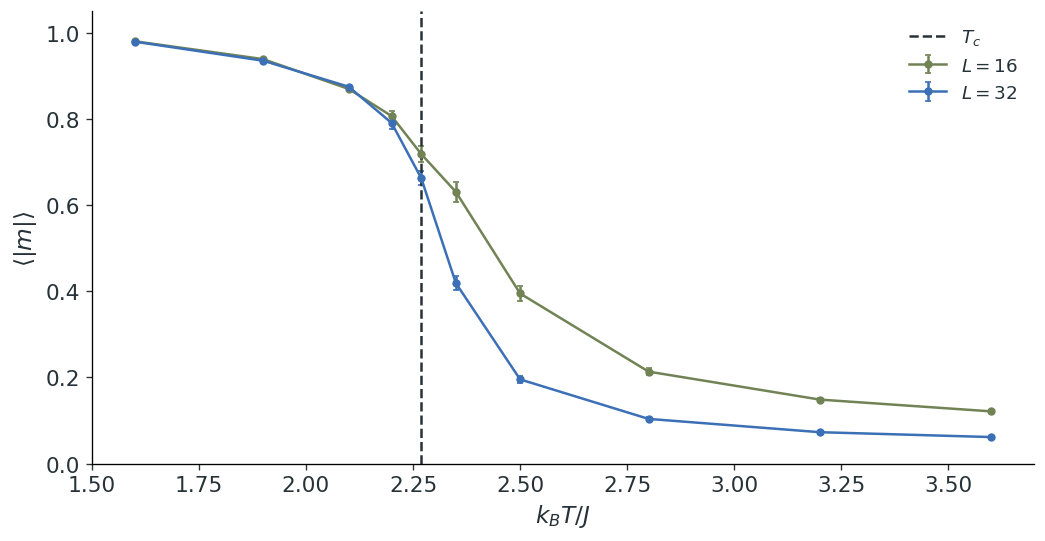

In [56]:
temperatures = np.array([1.6, 1.9, 2.1, 2.2, TC, 2.35, 2.5, 2.8, 3.2, 3.6])
phase_records = []
fig, ax = plt.subplots(figsize=(8.6, 4.4), layout='constrained')
for side, color in [(16, OLIVE), (32, BLUE)]:
    means = []; errors = []
    for ti, temperature in enumerate(temperatures):
        samples = sample_lattices(side, temperature, seed=93000+side*100+ti, draws=256)
        model_samples[(temperature, side)] = samples
        magnitudes = np.abs(samples.mean(axis=(-1, -2)))
        blocks = magnitudes.reshape(2, 16, -1).mean(axis=-1).ravel()
        means.append(blocks.mean()); errors.append(blocks.std(ddof=1)/np.sqrt(len(blocks)))
        phase_records.append((side, temperature, means[-1], errors[-1]))
    ax.errorbar(temperatures, means, yerr=errors, fmt='o-', color=color, ms=4, capsize=2, label=fr'$L={side}$')
ax.axvline(TC, color=INK, ls='--', label=r'$T_c$')
ax.set(xlabel='$k_BT/J$', ylabel=r'$\langle|m|\rangle$', ylim=(0, 1.05))
ax.legend(frameon=False)
plt.show()

### A continuous phase transition

The infinite square lattice at $h=0$ has a critical temperature given by:

$$
\frac{k_BT_c}{J}=\frac{2}{\ln(1+\sqrt2)}\simeq2.269.
$$

As the temperature approaches $T_c$ from below, the spontaneous magnetization decreases continuously to zero.

For a finite lattice, this transition is rounded rather than sharp.

### Correlations in the 2D lattice

We measure correlations by averaging the product of spins separated by $n$ lattice steps. $\mu=\langle s_i\rangle$ is the mean spin at any site, averaged over equilibrium configurations.

Even independent spins have an average product of $\mu^2$, so we need to subtract this mean to calculate the **covariance**, which measures whether their fluctuations occur together.

Dividing by $1-\mu^2$, the variance of a single spin, gives the normalized correlation:

$$
C(n)=\frac{\langle s_i s_j\rangle_n-\mu^2}{1-\mu^2}.
$$

This makes $C(0)=1$, because a spin is perfectly correlated with itself. When $\mu=0$, the expression reduces to the spin-product correlation from Lecture 8.


In [57]:
# Periodic spatial autocorrelation; the zero-field ensemble mean is exactly zero.
def radial_spin_correlations(samples):
    side = samples.shape[-1]
    separation = np.minimum(np.arange(side), side-np.arange(side))
    radius = np.hypot(separation[:, None], separation[None, :])
    bins = np.floor(radius+.5).astype(int)
    count = np.bincount(bins.ravel())
    n = np.bincount(bins.ravel(), weights=radius.ravel())/count
    raw = []; centered = []
    for spins in samples.reshape(-1, side, side):
        covariance = np.fft.ifft2(np.abs(np.fft.fft2(spins))**2).real/spins.size
        assert np.isclose(covariance[0, 0], 1)
        raw.append(np.bincount(bins.ravel(), weights=covariance.ravel())/count)
        m = spins.mean()
        # This separate estimator is used only for the later group-centering control.
        residual = covariance-m*m
        assert abs(residual.sum()) < 1e-8
        centered.append(np.bincount(bins.ravel(), weights=(residual/(1-m*m)).ravel())/count)
    return n, np.asarray(raw).reshape(2, -1, len(n)), np.asarray(centered).reshape(2, -1, len(n))

ising_correlations = {}
for ti, temperature in enumerate([TC, 3.0]):
    for side in [16, 32, 64, 128]:
        if (temperature, side) not in model_samples:
            model_samples[(temperature, side)] = sample_lattices(side, temperature, draws=1024 if side == 128 else 256, burn=512 if side == 128 else 192, seed=96000+10000*ti+side*100)
        n, raw, centered = radial_spin_correlations(model_samples[(temperature, side)])
        blocks = raw.reshape(2, 16, -1, len(n)).mean(axis=2).reshape(-1, len(n))
        ising_correlations[(temperature, side)] = {'n': n, 'C': raw.mean(axis=(0, 1)),
            'se': blocks.std(axis=0, ddof=1)/np.sqrt(len(blocks)),
            'centered': centered.mean(axis=(0, 1))}

### Correlations above $T_c$ have a length scale, at $T_c$ they don't!

Above $T_c$, correlations decay approximately exponentially, with a characteristic **correlation length** $\xi$. Spins separated by distances much larger than $\xi$ are only weakly correlated.

At $T_c$, the correlation instead decays as a power law:

$$
C(n)\propto n^{-1/4},\qquad 1\ll n\ll L.
$$

A power law has no characteristic decay length: doubling the separation reduces the correlation by the same proportion wherever we start within the scaling range. Correlations therefore occur on all scales between the lattice spacing and the system size, although they become weaker with distance.


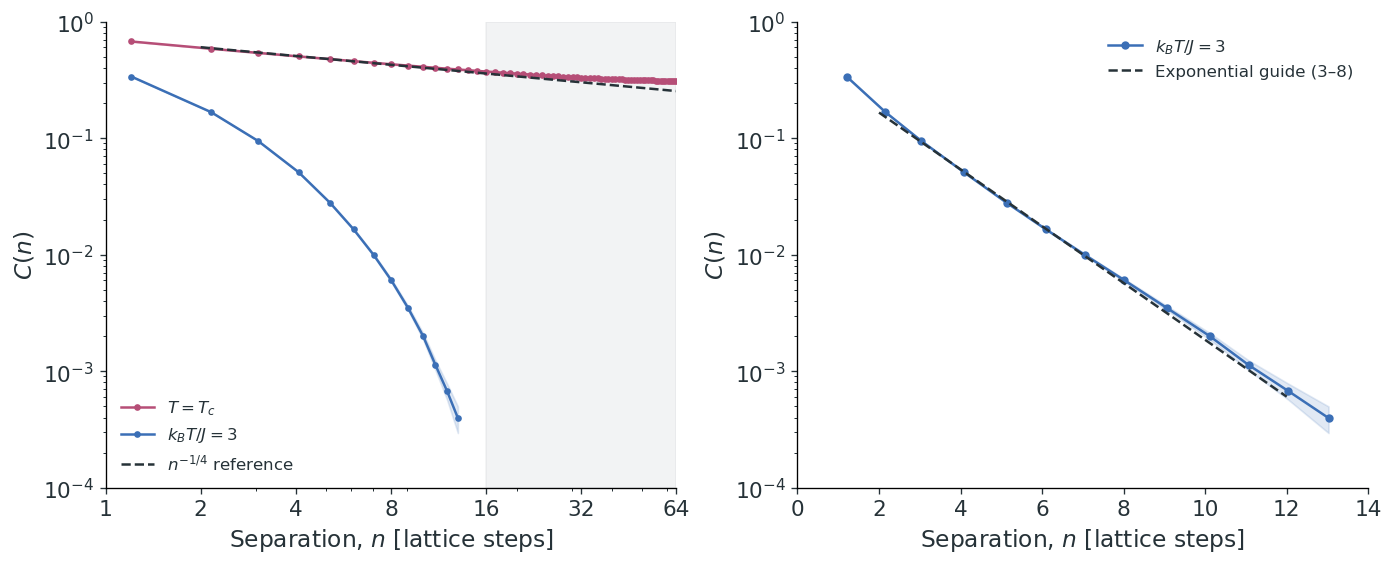

In [58]:
# Plot conventions: L=128; theoretical exponent -1/4 with amplitude matched at n=3–8.
# Gray shading marks n>L/8 as a visual reminder of finite-size effects, not a sharp cutoff.
# Bands show one block-based standard error; retain positive signals exceeding 3 SE.
from matplotlib.ticker import FixedLocator, FuncFormatter, NullFormatter

# One large lattice separates the temperature comparison from finite-size effects.
side = 128
critical = ising_correlations[(TC, side)]
warm = ising_correlations[(3.0, side)]
reference = (critical['n'] >= 3) & (critical['n'] <= 8)
# Fix the exponent at its theoretical value; match only the vertical amplitude.
amplitude = np.mean(critical['C'][reference] * critical['n'][reference]**.25)
guide = np.geomspace(2, side/2, 200)
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.6), layout='constrained')
for result, color, label in [(critical, PINK, r'$T=T_c$'), (warm, BLUE, r'$k_BT/J=3$')]:
    n, c, se = result['n'], result['C'], result['se']
    valid = (n >= 1) & (n <= side/2) & (c > 3*se)
    x, y, e = n[valid], c[valid], se[valid]
    axes[0].loglog(x, y, 'o-', color=color, ms=3, label=label)
    axes[0].fill_between(x, y-e, y+e, color=color, alpha=.15)
axes[0].loglog(guide, amplitude*guide**(-.25), '--', color=INK, label=r'$n^{-1/4}$ reference')
for ax in axes[:1]:
    ax.axvspan(side/8, side/2, color=GREY, alpha=.12)
    ax.set_xlim(1, side/2)
    ax.xaxis.set_major_locator(FixedLocator([1, 2, 4, 8, 16, 32, 64]))
    ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x:g}'))
    ax.xaxis.set_minor_formatter(NullFormatter())
axes[0].set(ylabel='$C(n)$', ylim=(.0001, 1))
n, c, se = warm['n'], warm['C'], warm['se']
valid = (n >= 1) & (n <= side/8) & (c > 3*se)
axes[1].semilogy(n[valid], c[valid], 'o-', color=BLUE, ms=4, label=r'$k_BT/J=3$')
axes[1].fill_between(n[valid], c[valid]-se[valid], c[valid]+se[valid], color=BLUE, alpha=.15)
# A visual exponential guide, not a precision correlation-length estimate.
fit = valid & (n >= 3) & (n <= 8)
slope, intercept = np.polyfit(n[fit], np.log(c[fit]), 1)
x = np.linspace(2, 12, 100)
axes[1].semilogy(x, np.exp(intercept+slope*x), '--', color=INK, label='Exponential guide (3–8)')
axes[1].set(xlim=(0, 14), ylabel='$C(n)$', ylim=(.0001, 1))
for ax in axes:
    ax.set_xlabel('Separation, $n$ [lattice steps]')
    ax.legend(frameon=False, fontsize=10, loc='upper right')
axes[0].legend(frameon=False, fontsize=10, loc='lower left')
plt.show()


### System size limits the correlations at $T_c$ for finite populations

- Above $T_c$, the correlation length $\xi$ sets the scale of the decay. Once the lattice is much larger than $\xi$, increasing its size leaves the correlation curve nearly unchanged.

- At $T_c$, there is no finite intrinsic correlation length. A larger lattice extends the range of scales over which we can observe the power law; the finite system size, rather than a fixed $\xi$, limits that range.


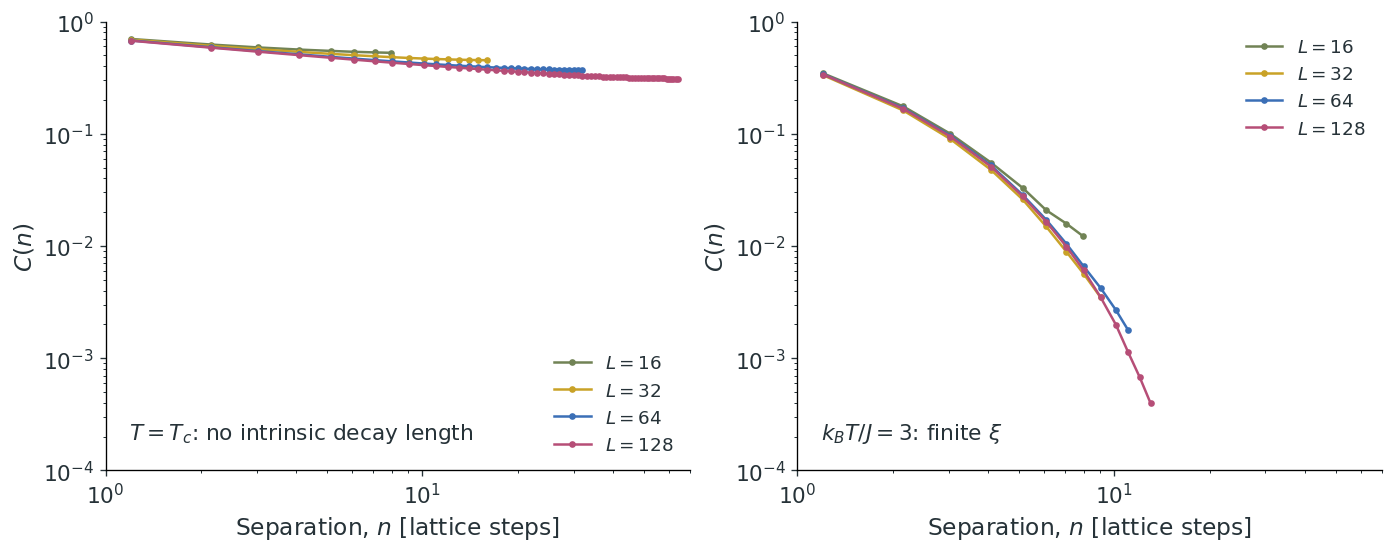

In [59]:
# Finite-size comparison, separate from the decay-law demonstration.
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.5), layout='constrained')
for ax, temperature in zip(axes, [TC, 3.0]):
    for side, color in zip([16, 32, 64, 128], [OLIVE, GOLD, BLUE, PINK]):
        result = ising_correlations[(temperature, side)]
        n, c, se = result['n'], result['C'], result['se']
        valid = (n >= 1) & (n <= side/2) & (c > 3*se)
        ax.loglog(n[valid], c[valid], 'o-', color=color, ms=3, label=fr'$L={side}$')
    ax.set(xlabel='Separation, $n$ [lattice steps]', ylabel='$C(n)$', xlim=(1, 70), ylim=(.0001, 1))
    ax.text(.04, .07, r'$T=T_c$: no intrinsic decay length' if temperature == TC else r'$k_BT/J=3$: finite $\xi$', transform=ax.transAxes)
    ax.legend(frameon=False)
plt.show()


## Scale-free correlations in Starling flocks

<img src="../media/spatial-order/cavagna-2010-figure-2.png" width="850" alt="Published starling orientation and speed correlations, and their first-zero-crossing ranges versus flock extent.">

### The correlation length grows with flock size

$$
\xi_0\propto L.
$$

The correlations are **scale-free**, as far as the experiment can see. We saw this in the 2D Ising model at $T=T_c$.

**Is the flock at a critical point?**


## Returning to the lipid membranes...

**Giant plasma membrane vesicle (GPMV):** made from a real cell containing *many* lipid species.

Cooling separates this mixture into two phases with different proportions of lipids based on order of the hydrocarbon tails

| Liquid-ordered | Liquid-disordered |
| --- | --- |
| Tails mostly extended and aligned | Tails more bent and variably oriented |

**DiI-C12 dye collects preferentially in the disordered phase**


In [60]:
movie('membranes/gpmv-critical-cooling-reheating.mp4')

### Measuring correlations in the membrane images

**Intensity fluctuations** $\delta I(\mathbf x)$: fluorescence intensity after subtracting the smooth background.

Spatial covariance:

$$
G_I(\mathbf r)=\langle\delta I(\mathbf x)\,\delta I(\mathbf x+\mathbf r)\rangle.
$$

1. We avoid the bright rim (why?).
2. Subtracting a fitted smooth intensity profile from each frame leaves local fluctuations.

   ```python
   residuals = pixels - basis @ np.linalg.lstsq(basis, pixels, rcond=None)[0]
   ```

3. We can use [a Fourier transform (FFT) and convolution to compute the covariance](https://www.dspguide.com/ch24/6.htm) without large nested loops. Reversing the image in both directions makes the convolution an autocorrelation; dividing by the number of valid pairs at each separation gives the average product.

   ```python
   products = fftconvolve(field, field[::-1, ::-1], mode='full')
   curve = np.bincount(bins.ravel(), weights=products.ravel()) / np.maximum(counts, 1)
   ```

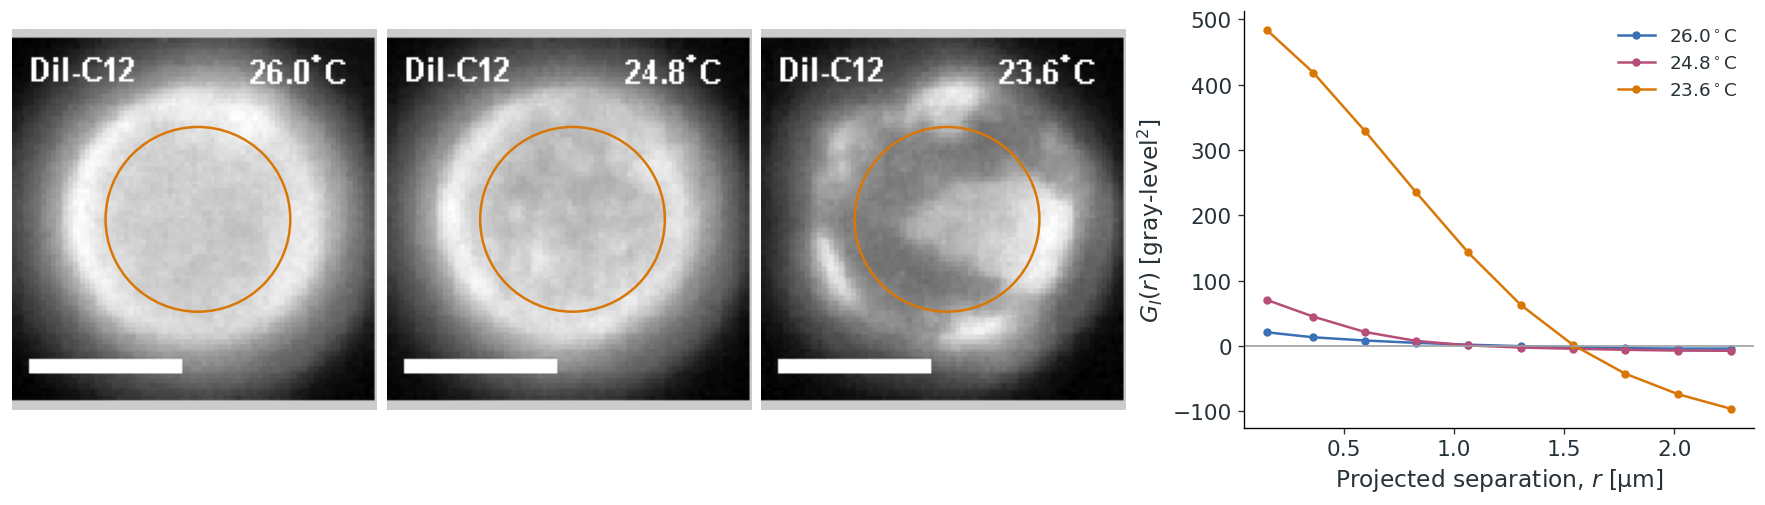

In [11]:
from scipy.signal import fftconvolve
membrane = np.load(DATA/'membranes/gpmv-three-temperature-blocks.npz')
frames = membrane['frames']; temperatures_c = membrane['temperature_c']
pixel_um = float(membrane['pixel_um']); cx, cy = membrane['roi_center_xy']; radius_px = float(membrane['roi_radius_px'])
yy, xx = np.indices(frames.shape[-2:])
mask = (xx-cx)**2+(yy-cy)**2 < radius_px**2
basis = np.column_stack([np.ones(mask.sum()), (xx[mask]-cx)/radius_px,
    (yy[mask]-cy)/radius_px, ((xx[mask]-cx)**2+(yy[mask]-cy)**2)/radius_px**2])
pair_count = fftconvolve(mask.astype(float), mask[::-1, ::-1].astype(float), mode='full')
dy, dx = np.indices(pair_count.shape)
separation_px = np.hypot(dx-(frames.shape[-1]-1), dy-(frames.shape[-2]-1))
bins = np.floor(separation_px/3).astype(int)
counts = np.bincount(bins.ravel(), weights=pair_count.ravel())
membrane_r = np.bincount(bins.ravel(), weights=(pair_count*separation_px).ravel())/np.maximum(counts, 1)*pixel_um
membrane_curves = []; membrane_variances = []
for block in frames:
    curves = []; variances = []
    for image in block:
        pixels = image[mask].astype(float)
        residuals = pixels-basis@np.linalg.lstsq(basis, pixels, rcond=None)[0]
        field = np.zeros(image.shape); field[mask] = residuals
        products = fftconvolve(field, field[::-1, ::-1], mode='full')
        curves.append(np.bincount(bins.ravel(), weights=products.ravel())/np.maximum(counts, 1))
        variances.append(np.mean(residuals**2))
    membrane_curves.append(np.mean(curves, axis=0)); membrane_variances.append(np.mean(variances))
fig, axes = plt.subplots(1, 4, figsize=(14.6, 4.1), layout='constrained',
                         gridspec_kw={'width_ratios': [1, 1, 1, 1.4]})
for index, ax in enumerate(axes[:3]):
    ax.imshow(frames[index, 4], cmap='gray', vmin=0, vmax=255)
    ax.add_patch(Circle((cx, cy), radius_px, fill=False, color=ORANGE, lw=1.5))
    ax.set_axis_off()
for temperature, curve, color in zip(temperatures_c, membrane_curves, [BLUE, PINK, ORANGE]):
    valid = (membrane_r <= 2.4) & (counts > 10000)
    axes[3].plot(membrane_r[valid], curve[valid], 'o-', color=color, ms=4, label=fr'${temperature:.1f}^\circ$C')
axes[3].axhline(0, color=GREY, lw=1)
axes[3].set(xlabel='Projected separation, $r$ [µm]', ylabel=r'$G_I(r)$ [gray-level$^2$]')
axes[3].legend(frameon=False)
plt.show()

- Cooling from 26.0 to 24.8 °C makes the short-range fluctuations much stronger

- At 23.6 °C, large domains appear and the covariance extends much farther


### Correlation length near the transition

- In artificial lipid vesicles, $\xi$ grows as $T$ approaches $T_c$:

$$
\xi\propto\left|\frac{T-T_c}{T_c}\right|^{-\nu}.
$$

- Measured: $\nu=1.2\pm0.2$. 

- *2D Ising Model: $\nu=1$*.

[Honerkamp-Smith et al. (2008)](https://doi.org/10.1529/biophysj.107.128421)


## Spatial organization in a moving flock

- Four synchronized cameras filmed wild jackdaws turning near winter roosts in Cornwall at 60 frames/s

- Matching birds across views gave each bird’s 3D position and velocity

- We will analyze one transit flock of **196 birds**

<video src="../media/flocking/jackdaw-raw-camera-related-study.mp4" controls muted playsinline width="720"></video>

[Ling et al., *J. R. Soc. Interface* (2019)](https://doi.org/10.1098/rsif.2019.0450) · [Ling et al., *Nature Communications* (2019), Supplementary Movie 1](https://www.nature.com/articles/s41467-019-13281-4#Sec15)

Subtracting the flock center, here is the residual motion:

In [62]:
flock = pd.read_csv(DATA/'flocking/jackdaw-transit-04.csv')
assert np.isfinite(flock.to_numpy()).all()
assert not flock.duplicated(['bird_id', 'time_s']).any()
times = np.sort(flock.time_s.unique())
bird_count = flock.bird_id.nunique()
assert (flock.groupby('time_s').size() == bird_count).all()
snapshot_time = times[len(times)//2]
snapshot = flock[flock.time_s == snapshot_time].sort_values('bird_id')
bird_positions = snapshot[['x_m', 'y_m', 'z_m']].to_numpy()
bird_velocities = snapshot[['vx_m_s', 'vy_m_s', 'vz_m_s']].to_numpy()

# Replay the observed positions, centered on the moving flock, at acquisition speed.
# The clock uses the supplied timestamps, never an assumed frame number.
from matplotlib.animation import FuncAnimation, FFMpegWriter
replay_frames = []
for time in times[::3]:
    frame = flock[flock.time_s == time].sort_values('bird_id')
    xy = frame[['x_m', 'y_m']].to_numpy(); xy -= xy.mean(axis=0)
    replay_frames.append((time, xy))
all_xy = np.concatenate([xy for _, xy in replay_frames])
limits = np.max(np.abs(all_xy), axis=0)+5
fig, ax = plt.subplots(figsize=(7.2, 4.7), layout='constrained')
points = ax.scatter(*replay_frames[0][1].T, s=14, color=BLUE)
clock = ax.text(.04, .94, '', transform=ax.transAxes)
ax.set(xlim=(-limits[0], limits[0]), ylim=(-limits[1], limits[1]), aspect='equal',
       xlabel='x relative to flock center [m]', ylabel='y relative to flock center [m]')
def update_flock(index):
    time, xy = replay_frames[index]
    points.set_offsets(xy); clock.set_text(f'time = {time:.2f} s')
    return points, clock
animation = FuncAnimation(fig, update_flock, frames=len(replay_frames), interval=50, blit=False)
replay_path = MEDIA/'flocking/jackdaw-transit-04-reconstruction.mp4'
animation.save(replay_path, writer=FFMpegWriter(fps=20), dpi=110)
plt.close(fig)
movie('flocking/jackdaw-transit-04-reconstruction.mp4')

### Measuring the frequency of neighbor separations

Neighbors at distances from $r$ to $r+\Delta r$ lie in a ring with area:

$$
A_{\mathrm{ring}}=\pi[(r+\Delta r)^2-r^2].
$$

We compare the observed neighbor count with the count expected for independent positions in the same area.

### The pair correlation function $g(r)$

For $N$ total points inside total area $A$, the *radial distribution function*, also called the *pair correlation function*, is:

$$
\widehat g(r)=
\frac{\text{observed pairs in the ring}}
{N(N-1)A_{\mathrm{ring}}/A}.
$$

| Pair count relative to the reference | Interpretation |
| --- | --- |
| $g(r)=1$ | Same expected count |
| $g(r)<1$ | Fewer pairs at this separation than random |
| $g(r)>1$ | More pairs at this separation than random |

In [63]:
# Synthetic point patterns in a periodic rectangle. Distances use the minimum image.
from matplotlib.patches import Wedge

PAIR_BOX = np.array([20., 10*np.sqrt(3)])
PAIR_N = 400
PAIR_RHO = PAIR_N / np.prod(PAIR_BOX)
PAIR_SPACING = 1/np.sqrt(PAIR_RHO)
PAIR_COLORS = {'Random': BLUE, 'Excluded volume': OLIVE, 'Clustered': PINK}

def pair_displacements(points, box=None):
    delta = points[None, :, :] - points[:, None, :]
    if box is not None:
        delta -= box * np.rint(delta/box)
    return delta

def radial_distribution(points, edges, box):
    """Ordered pairs, no self-pairs; random fixed-N patterns have mean g=1.

    Periodic shells must fit inside half the shortest box dimension.
    """
    delta = pair_displacements(points, box)
    distance = np.linalg.norm(delta, axis=-1)
    distinct = ~np.eye(len(points), dtype=bool)
    counts = np.histogram(distance[distinct], bins=edges)[0]
    shell_area = np.pi*np.diff(edges**2)
    expected = len(points)*(len(points)-1)*shell_area/np.prod(box)
    return counts/expected

def excluded_points(rng, count=PAIR_N, diameter=None, box=PAIR_BOX):
    diameter = 0.65*PAIR_SPACING if diameter is None else diameter
    points = []
    for attempt in range(200000):
        candidate = rng.random(2)*box
        if points:
            delta = np.array(points)-candidate
            delta -= box*np.rint(delta/box)
            if np.any(np.sum(delta**2, axis=1) < diameter**2):
                continue
        points.append(candidate)
        if len(points) == count:
            return np.array(points)
    raise RuntimeError('Requested exclusion is too large for this packing.')

pair_rng = np.random.default_rng(9567)
pair_patterns = {
    'Random': pair_rng.random((PAIR_N, 2))*PAIR_BOX,
    'Excluded volume': excluded_points(pair_rng),
}
parents = pair_rng.random((20, 2))*PAIR_BOX
pair_patterns['Clustered'] = (parents[pair_rng.integers(20, size=PAIR_N)]
    + pair_rng.normal(0, 0.38*PAIR_SPACING, (PAIR_N, 2))) % PAIR_BOX

pair_edges = np.arange(0, 6.01, .15)*PAIR_SPACING
pair_r = (pair_edges[:-1]+pair_edges[1:])/2
pair_g = {name: radial_distribution(points, pair_edges, PAIR_BOX)
          for name, points in pair_patterns.items()}

### We average the neighbor counts centered on every observed point


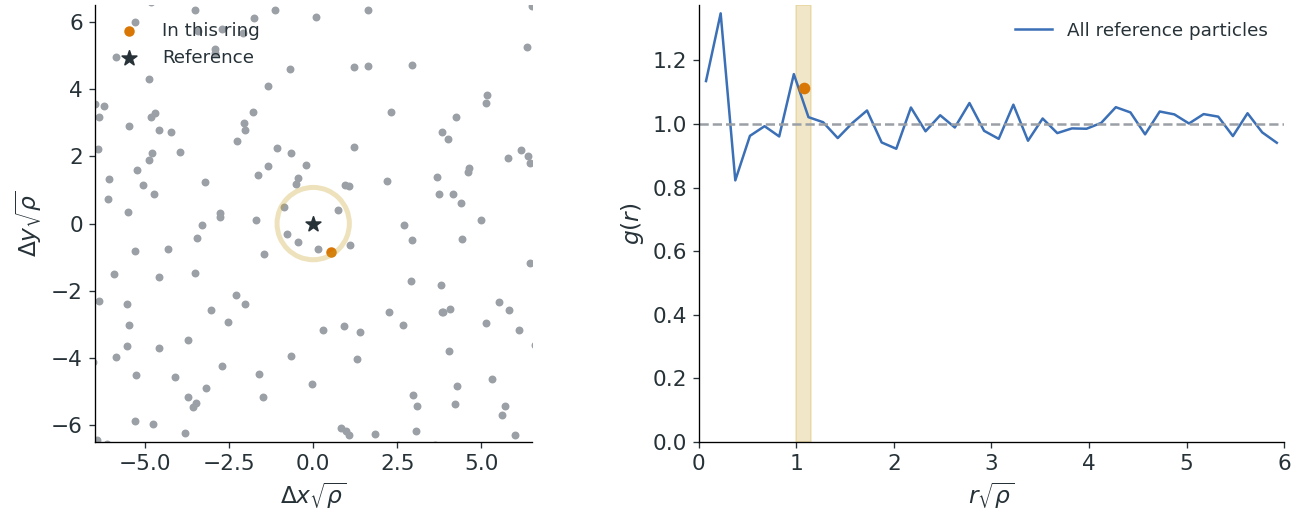

In [64]:
# Ring counts around one reference and the average over all references.
import ipywidgets as widgets
import io
from matplotlib.figure import Figure
from matplotlib.backends.backend_agg import FigureCanvasAgg

class PairCorrelationDemo:
    def __init__(self):
        style = {'description_width': '110px'}
        layout = widgets.Layout(width='390px')
        self.pattern = widgets.Dropdown(options=list(pair_patterns), value='Random',
            description='Pattern', style=style, layout=layout)
        self.radius = widgets.FloatSlider(value=1., min=0., max=5.5, step=0.05,
            description='r √ρ', continuous_update=False, style=style, layout=layout)
        self.width = widgets.FloatSlider(value=0.15, min=0.05, max=0.5, step=0.05,
            description='Δr √ρ', continuous_update=False, style=style, layout=layout)
        self.reference = widgets.IntSlider(value=0, min=0, max=PAIR_N-1,
            description='Reference index', continuous_update=False, style=style, layout=layout)
        self.picture = widgets.Image(format='png', layout=widgets.Layout(width='100%'))
        self.status = widgets.HTML()
        self.ui = widgets.VBox([widgets.HBox([
            widgets.VBox([self.pattern, self.reference]), widgets.VBox([self.radius, self.width])],
            layout=widgets.Layout(flex_flow='row wrap')), self.status, self.picture])
        for control in [self.pattern, self.radius, self.width, self.reference]:
            control.observe(self.render, names='value')
        self.render()

    def render(self, change=None):
        points = pair_patterns[self.pattern.value]
        r = self.radius.value*PAIR_SPACING; dr = self.width.value*PAIR_SPACING
        delta = points-points[self.reference.value]
        delta -= PAIR_BOX*np.rint(delta/PAIR_BOX)
        distance = np.linalg.norm(delta, axis=1)
        selected = (distance >= r) & (distance < r+dr)
        selected[self.reference.value] = False
        observed = int(selected.sum())
        expected = (PAIR_N-1)/np.prod(PAIR_BOX)*np.pi*((r+dr)**2-r**2)
        ring_g = radial_distribution(points, np.array([r, r+dr]), PAIR_BOX)[0]
        edges = np.arange(0, 6.001, self.width.value)*PAIR_SPACING
        centers = (edges[:-1]+edges[1:])/2
        values = radial_distribution(points, edges, PAIR_BOX)
        fig = Figure(figsize=(10.8, 4.3), layout='constrained')
        canvas = FigureCanvasAgg(fig); axes = fig.subplots(1, 2)
        xy = delta/PAIR_SPACING
        axes[0].scatter(*xy.T, s=14, color=GREY)
        axes[0].scatter(*xy[selected].T, s=28, color=ORANGE, label='In this ring')
        axes[0].scatter([0], [0], s=85, marker='*', color=INK, label='Reference')
        axes[0].add_patch(Wedge((0, 0), (r+dr)/PAIR_SPACING, 0, 360,
            width=dr/PAIR_SPACING, facecolor=GOLD, alpha=0.3))
        axes[0].set(xlim=(-6.5,6.5), ylim=(-6.5,6.5), aspect='equal',
            xlabel=r'$\Delta x\sqrt{\rho}$', ylabel=r'$\Delta y\sqrt{\rho}$')
        axes[0].legend(frameon=False, loc='upper left')
        axes[1].plot(centers/PAIR_SPACING, values, color=PAIR_COLORS[self.pattern.value],
            label='All reference particles')
        axes[1].axhline(1, color=GREY, ls='--')
        axes[1].axvspan(r/PAIR_SPACING, (r+dr)/PAIR_SPACING, color=GOLD, alpha=0.25)
        axes[1].plot([(r+dr/2)/PAIR_SPACING], [ring_g], 'o', color=ORANGE)
        axes[1].set(xlabel=r'$r\sqrt{\rho}$', ylabel='$g(r)$', xlim=(0,6), ylim=(0,None))
        axes[1].legend(frameon=False)
        stream = io.BytesIO(); canvas.print_png(stream); self.picture.value = stream.getvalue()
        self.status.value = (f'<b>{self.pattern.value}</b> · periodic boundaries · '
            f'This reference: {observed} neighbors / {expected:.2f} expected = {observed/expected:.2f}'
            f' · All references: g = {ring_g:.2f}')
        fig.clear()

    def close(self):
        for control in [self.ui, self.pattern, self.radius, self.width, self.reference,
                        self.picture, self.status]:
            control.close()

if 'pair_demo' in globals():
    pair_demo.close()
pair_demo = PairCorrelationDemo()
show_widget(pair_demo.ui, pair_demo.picture.value)

### Exclusion and aggregation leave different signatures

All three patterns contain the same number of particles in the same area, so their differences reflect spatial organization rather than mean density.

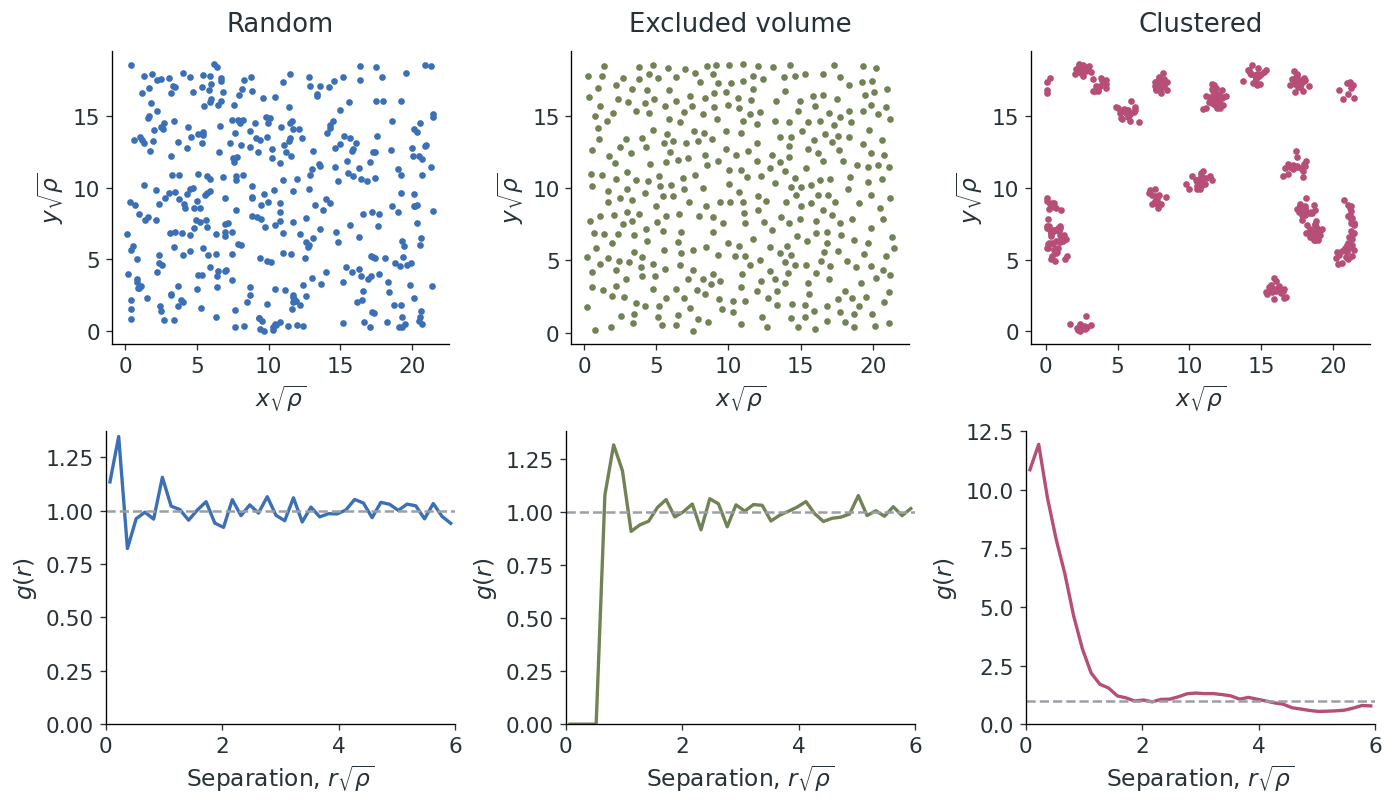

In [65]:
fig, axes = plt.subplots(2, 3, figsize=(11.5, 6.6), layout='constrained')
for column, (name, points) in enumerate(pair_patterns.items()):
    color = PAIR_COLORS[name]
    axes[0, column].scatter(*(points/PAIR_SPACING).T, s=9, color=color)
    axes[0, column].set(xlabel=r'$x\sqrt{\rho}$', ylabel=r'$y\sqrt{\rho}$', aspect='equal')
    axes[0, column].set_title(name, pad=12)
    axes[1, column].plot(pair_r/PAIR_SPACING, pair_g[name], color=color, lw=2)
    axes[1, column].axhline(1, color=GREY, ls='--')
    axes[1, column].set(xlabel=r'Separation, $r\sqrt{\rho}$', ylabel='$g(r)$', xlim=(0, 6), ylim=(0, None))
plt.show()

### Measuring pair correlations in the flock

- Count birds in 3D spherical shells around each bird

- Use only shells that fit entirely inside the flock; mean density is $\rho=(N-1)/V$, where $V$ is the flock’s convex-hull volume

- $g(r)=$ mean observed neighbors per center $/\rho\,\Delta V_{\rm shell}$


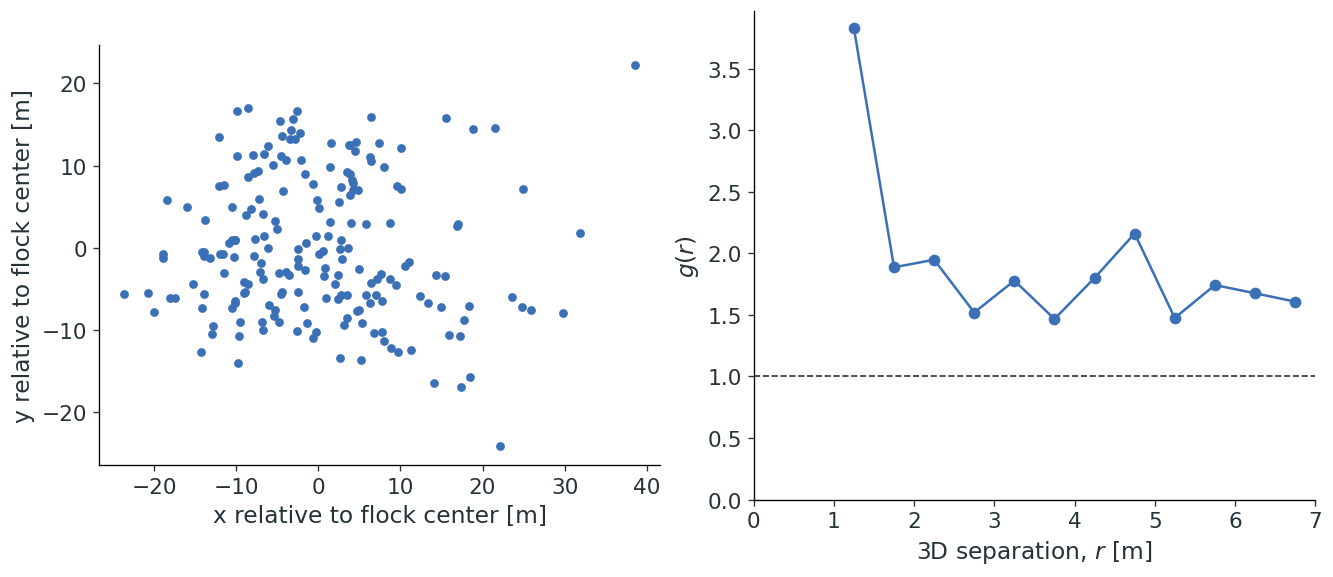

In [66]:
from scipy.spatial import ConvexHull
from scipy.spatial.distance import pdist, cdist

bird_pairs = np.triu_indices(bird_count, 1)
bird_distances = pdist(bird_positions)

# Keep the wider distance bins for the velocity-correlation calculation below.
bird_edges = np.linspace(0, bird_distances.max(), 14)
bird_r = (bird_edges[:-1] + bird_edges[1:])/2
bird_bins = np.minimum(np.digitize(bird_distances, bird_edges)-1, len(bird_r)-1)
bird_pair_counts = np.bincount(bird_bins, minlength=len(bird_r))
center = bird_positions.mean(axis=0)

# Standard 3D radial distribution: count neighbors in shells around birds whose
# entire shell lies inside the observed convex hull.
hull = ConvexHull(bird_positions)
planes = hull.equations
boundary_distance = -(bird_positions @ planes[:, :3].T + planes[:, 3]) / np.linalg.norm(planes[:, :3], axis=1)
interior_radius = boundary_distance.min(axis=1)
separations = cdist(bird_positions, bird_positions)
np.fill_diagonal(separations, np.inf)

rdf_edges = np.arange(0, 7.01, 0.5)
rdf_r = (rdf_edges[:-1] + rdf_edges[1:])/2
rdf_counts = []
rdf_expected = []
for inner, outer in zip(rdf_edges[:-1], rdf_edges[1:]):
    centers = interior_radius >= outer
    rdf_counts.append(((separations[centers] >= inner) & (separations[centers] < outer)).sum())
    shell_volume = 4*np.pi*(outer**3-inner**3)/3
    rdf_expected.append(centers.sum() * (bird_count-1)/hull.volume * shell_volume)
rdf_counts = np.asarray(rdf_counts)
rdf_expected = np.asarray(rdf_expected)
rdf_g = rdf_counts / rdf_expected
rdf_show = rdf_expected >= 10

fig, axes = plt.subplots(1, 2, figsize=(11, 4.7), layout='constrained')
xy = bird_positions[:, :2]-center[:2]
axes[0].scatter(*xy.T, s=18, color=BLUE)
axes[0].set(xlabel='x relative to flock center [m]', ylabel='y relative to flock center [m]', aspect='equal')
axes[1].plot(rdf_r[rdf_show], rdf_g[rdf_show], 'o-', color=BLUE)
axes[1].axhline(1, color=INK, ls='--', lw=1)
axes[1].set(xlabel='3D separation, $r$ [m]', ylabel='$g(r)$', xlim=(0, 7), ylim=(0, None))
plt.show()


- Birds are clumpy!


## Motion in the same flock

We can also look at velocity correlations

- Subtracting the flock's mean velocity leaves each bird's deviation:

$$
\delta\mathbf v_i=\mathbf v_i-\bar{\mathbf v}.
$$


### Velocity correlations

For birds separated by $r$, compare their velocity deviations:

$$
\widehat C_v(r)=
\frac{\langle\delta\mathbf v_i\cdot\delta\mathbf v_j\rangle_{\text{pairs at }r}}
{\langle|\delta\mathbf v_i|^2\rangle_{\text{birds}}}.
$$

$C_v(r)>0$: birds deviate from the flock's motion in similar directions.


### Shuffling tests whether nearby birds move together

- Keep the **same positions and velocities**, but randomly reassign velocities among birds

- Overall motion and speeds stay the same; local position–velocity relationships are broken

- Compare the observed $C_v(r)$ with 500 shuffles


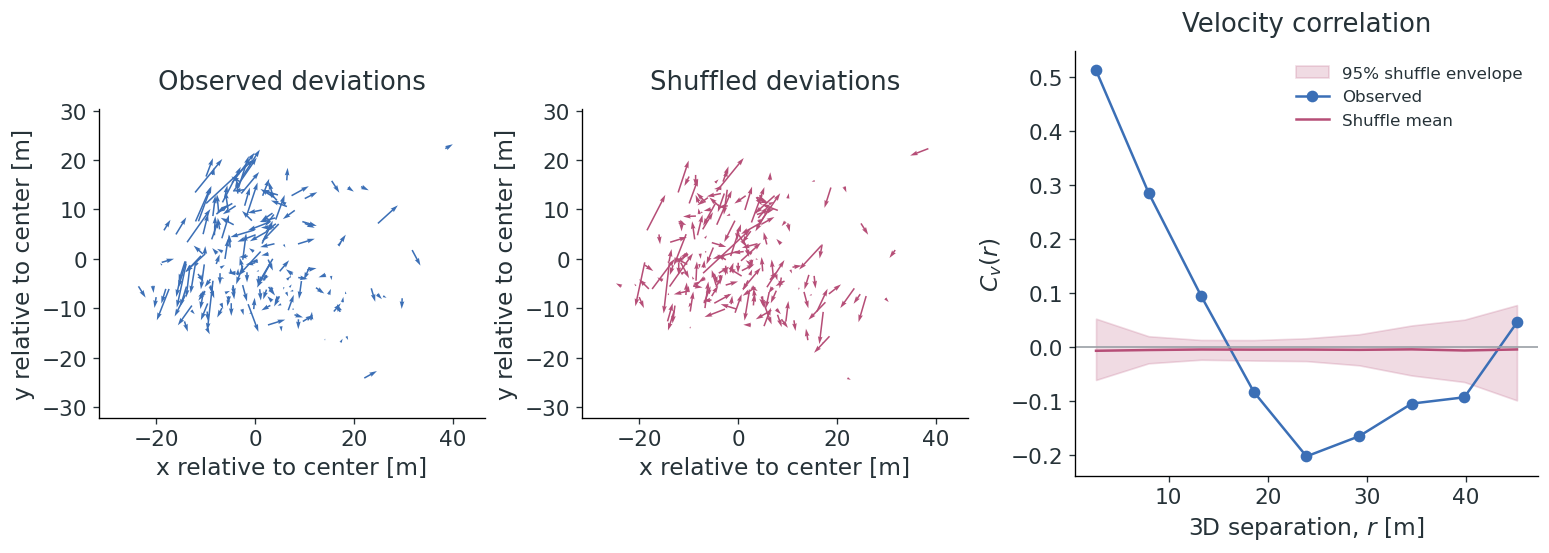

In [67]:
bird_dv = bird_velocities-bird_velocities.mean(axis=0)
bird_variance = np.mean(np.sum(bird_dv**2, axis=1))
def velocity_correlation(deviations):
    products = (deviations @ deviations.T)[bird_pairs]/bird_variance
    return np.bincount(bird_bins, weights=products, minlength=len(bird_r))/bird_pair_counts
def heading_alignment(velocities):
    directions = velocities/np.linalg.norm(velocities, axis=1)[:, None]
    return np.linalg.norm(directions.mean(axis=0))
rng = np.random.default_rng(20260930)
permutation = rng.permutation(bird_count)
shuffled_velocities = bird_velocities[permutation]
shuffle_curves = np.array([velocity_correlation(bird_dv[rng.permutation(bird_count)]) for _ in range(500)])
observed_velocity_curve = velocity_correlation(bird_dv)
assert np.allclose(shuffled_velocities.mean(axis=0), bird_velocities.mean(axis=0))
assert np.isclose(heading_alignment(shuffled_velocities), heading_alignment(bird_velocities))
valid_v = bird_pair_counts >= 200

fig, axes = plt.subplots(1, 3, figsize=(12.8, 4.5), layout='constrained', gridspec_kw={'width_ratios': [1, 1, 1.2]})
arrow_scale = np.percentile(np.linalg.norm(bird_dv[:, :2], axis=1), 90)/(max(np.ptp(xy, axis=0))*.09)
for ax, dv, label, color in [(axes[0], bird_dv, 'Observed deviations', BLUE),
    (axes[1], shuffled_velocities-shuffled_velocities.mean(axis=0), 'Shuffled deviations', PINK)]:
    arrows = ax.quiver(xy[:, 0], xy[:, 1], dv[:, 0], dv[:, 1], color=color, angles='xy', scale_units='xy', scale=arrow_scale, width=.004)
    ax.set(xlim=(xy[:, 0].min()-8, xy[:, 0].max()+8), ylim=(xy[:, 1].min()-8, xy[:, 1].max()+8),
           aspect='equal', xlabel='x relative to center [m]', ylabel='y relative to center [m]')
    ax.set_title(label, pad=12)
axes[2].fill_between(bird_r[valid_v], np.percentile(shuffle_curves, 2.5, axis=0)[valid_v],
    np.percentile(shuffle_curves, 97.5, axis=0)[valid_v], color=PINK, alpha=.2, label='95% shuffle envelope')
axes[2].plot(bird_r[valid_v], observed_velocity_curve[valid_v], 'o-', color=BLUE, label='Observed')
axes[2].plot(bird_r[valid_v], shuffle_curves.mean(axis=0)[valid_v], color=PINK, label='Shuffle mean')
axes[2].axhline(0, color=GREY, lw=1)
axes[2].set(xlabel='3D separation, $r$ [m]', ylabel='$C_v(r)$')
axes[2].set_title('Velocity correlation', pad=12)
axes[2].legend(frameon=False, fontsize=10)
plt.show()

**Nearby birds have similar velocity deviations after the flock's mean motion is removed**


### Bacterial swarms: position and motion

- *Bacillus subtilis* cells spread across a surface using flagella

- The two fields have the same reported cell density: **5.4 cells per 100 µm$^2$**

- Moving rafts (left) and mostly nonmotile clusters (right)

[Jeckel et al. (2019)](https://doi.org/10.1073/pnas.1811722116)


In [68]:
display(HTML(f"""<div style="display:flex;flex-wrap:wrap;gap:18px;align-items:start">
<video controls loop muted playsinline width="420" src="{MEDIA/'bacterial-swarms/moving-rafts.mp4'}"></video>
<video controls loop muted playsinline width="420" src="{MEDIA/'bacterial-swarms/nonmotile-clusters.mp4'}"></video>
</div>"""))

### Spatial correlations in the images

- With no cell-center coordinates, use image intensity $I(\mathbf x,t)$ as a spatial field

$$
C_I(r)=\frac{\langle\delta I(\mathbf x,t)\,\delta I(\mathbf x+\mathbf r,t)\rangle}
{\langle\delta I^2\rangle}.
$$

- Smooth over about 1 µm and subtract the broad image background


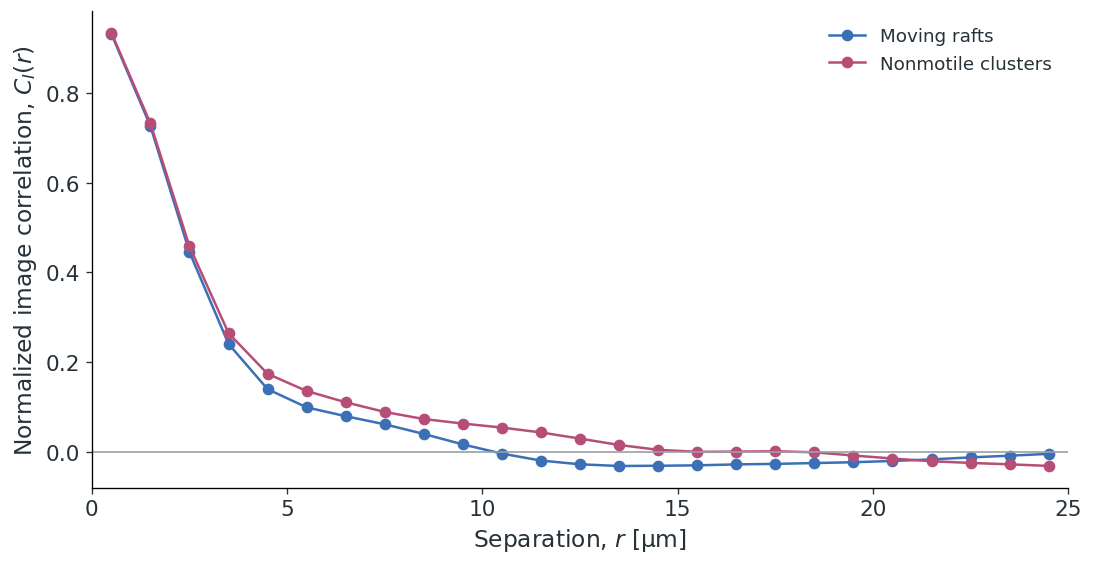

In [69]:
import cv2
from scipy.signal import fftconvolve

PIXEL_UM = 20/70  # from 20 µm bar in source movies

def swarm_frames(filename):
    cap = cv2.VideoCapture(str(MEDIA/'bacterial-swarms'/filename))
    frames = []
    while True:
        ok, frame = cap.read()
        if not ok:
            break
        frames.append(cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)[36:456, 10:500])
    cap.release()
    return frames

def radial_covariance(fields, pixel_step_um, edges):
    first = fields[0]
    ny, nx = first.shape[:2]
    summed = np.zeros((2*ny-1, 2*nx-1))
    for field in fields:
        centered = field.astype(float) - field.mean(axis=(0, 1), keepdims=True)
        if centered.ndim == 2:
            centered = centered[:, :, None]
        summed += sum(fftconvolve(centered[:, :, k],
                                  centered[::-1, ::-1, k], mode='full')
                      for k in range(centered.shape[2]))
    yy, xx = np.indices(summed.shape)
    dy, dx = yy-(ny-1), xx-(nx-1)
    overlap = (ny-abs(dy))*(nx-abs(dx))
    separation = np.hypot(dx, dy)*pixel_step_um
    covariance = []
    for inner, outer in zip(edges[:-1], edges[1:]):
        shell = (separation >= inner) & (separation < outer)
        covariance.append(summed[shell].sum()/overlap[shell].sum()/len(fields))
    on_site = summed[ny-1, nx-1]/(ny*nx*len(fields))
    return (edges[:-1]+edges[1:])/2, np.asarray(covariance), on_site

fig, ax = plt.subplots(figsize=(9, 4.6), layout='constrained')
for label, filename, color in [('Moving rafts', 'moving-rafts.mp4', BLUE),
                               ('Nonmotile clusters', 'nonmotile-clusters.mp4', PINK)]:
    frames = swarm_frames(filename)
    texture = []
    for gray in frames[::6]:
        coarse = cv2.GaussianBlur(gray.astype(float), (0, 0), 5)
        texture.append(coarse - cv2.GaussianBlur(coarse, (0, 0), 50))
    r_um, covariance, on_site = radial_covariance(texture, PIXEL_UM,
                                                   np.arange(0, 26, 1))
    ax.plot(r_um, covariance/on_site, 'o-', color=color, label=label)
ax.axhline(0, color=GREY, lw=1)
ax.set(xlabel='Separation, $r$ [µm]',
       ylabel=r'Normalized image correlation, $C_I(r)$',
       xlim=(0, 25))
ax.legend(frameon=False)
plt.show()


The two movies have similar short-range spatial image correlations


### Motion on top of the cells

- Arrows show local image motion after subtracting the frame-average motion. Both movies use the same scale: a 20-pixel arrow represents 80 µm/s.
- A dot means the estimated motion is too small to show as an arrow.


In [70]:
# Local image motion in the two microscopy movies (5 ms between source frames).
# Both panels use the same scale: 1 µm/s corresponds to 0.25 display pixels.
from subprocess import Popen, PIPE

FLOW_CROP = np.s_[36:456, 10:500]
FLOW_GRID_PX = 32
FLOW_ARROW_PX_PER_UM_S = 0.25
FLOW_DT_S = 0.005

def write_flow_overlay(name):
    source = MEDIA/'bacterial-swarms'/f'{name}.mp4'
    target = MEDIA/'bacterial-swarms'/f'{name}-flow-overlay.mp4'
    cap = cv2.VideoCapture(str(source))
    frames = []
    while True:
        ok, frame = cap.read()
        if not ok:
            break
        frames.append(frame)
    cap.release()
    if len(frames) < 2:
        raise ValueError(f'Cannot read source movie: {source}')
    height, width = frames[0].shape[:2]
    command = ['ffmpeg', '-y', '-loglevel', 'error', '-f', 'rawvideo',
               '-pixel_format', 'bgr24', '-video_size', f'{width}x{height}',
               '-framerate', '20', '-i', 'pipe:0', '-an', '-c:v', 'libx264',
               '-pix_fmt', 'yuv420p', '-crf', '20', str(target)]
    encoder = Popen(command, stdin=PIPE)
    for i, frame in enumerate(frames):
        j = min(i, len(frames)-2)
        before = cv2.cvtColor(frames[j], cv2.COLOR_BGR2GRAY)[FLOW_CROP]
        after = cv2.cvtColor(frames[j+1], cv2.COLOR_BGR2GRAY)[FLOW_CROP]
        flow = cv2.calcOpticalFlowFarneback(before, after, None,
                                            0.5, 4, 31, 5, 7, 1.5, 0)
        flow -= flow.mean(axis=(0, 1), keepdims=True)
        flow = cv2.GaussianBlur(flow, (0, 0), 8)  # smooth for legible arrows
        shown = frame.copy()
        for y in range(24, 420-24, FLOW_GRID_PX):
            for x in range(24, 490-24, FLOW_GRID_PX):
                arrow = flow[y, x] * (PIXEL_UM/FLOW_DT_S) * FLOW_ARROW_PX_PER_UM_S
                size = np.linalg.norm(arrow)
                if size > 24:
                    arrow *= 24/size
                start = (x+10, y+36)
                end = tuple(np.rint(np.array(start)+arrow).astype(int))
                cv2.circle(shown, start, 2, (0, 0, 0), -1, cv2.LINE_AA)
                if size >= 2:
                    cv2.arrowedLine(shown, start, end, (0, 0, 0), 3,
                                    cv2.LINE_AA, tipLength=0.28)
                    cv2.arrowedLine(shown, start, end, (40, 225, 250), 1,
                                    cv2.LINE_AA, tipLength=0.28)
                else:
                    cv2.circle(shown, start, 1, (40, 225, 250), -1, cv2.LINE_AA)
        encoder.stdin.write(shown.tobytes())
    encoder.stdin.close()
    if encoder.wait() != 0:
        raise RuntimeError(f'Could not encode {target}')
    return target

flow_movies = [write_flow_overlay(name) for name in
               ('moving-rafts', 'nonmotile-clusters')]
display(HTML(f"""<div style="display:flex;flex-wrap:wrap;gap:18px;align-items:start">
<video controls loop muted playsinline width="420" src="{flow_movies[0]}"></video>
<video controls loop muted playsinline width="420" src="{flow_movies[1]}"></video>
</div>"""))


### Motion correlations from the same movies

- Estimate local image velocity $\mathbf u(\mathbf x,t)$ from successive frames; subtract the frame's mean motion

$$
G_{\mathrm{flow}}(r)=\langle\delta\mathbf u(\mathbf x,t)\cdot\delta\mathbf u(\mathbf x+\mathbf r,t)\rangle.
$$

- Keep the covariance unnormalized so its height shows the strength of coordinated motion


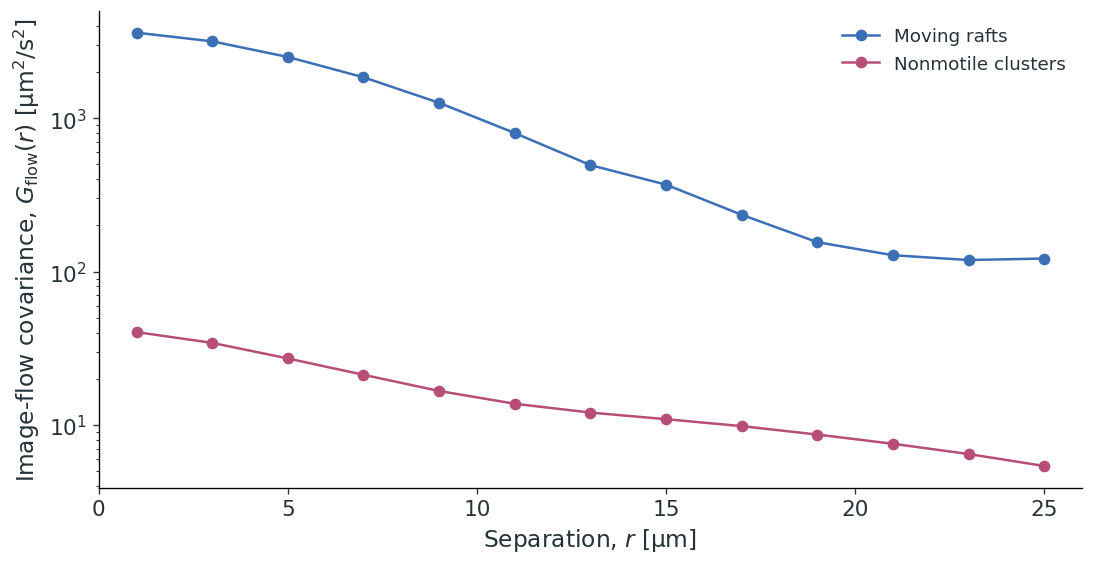

In [71]:
FRAME_DT_S = 0.005  # timestamps advance by 5 ms per source frame
GRID_STEP_PX = 8

def image_flow_covariance(filename):
    frames = swarm_frames(filename)
    velocities = []
    for before, after in zip(frames[:-1], frames[1:]):
        flow = cv2.calcOpticalFlowFarneback(before, after, None,
                                            0.5, 4, 31, 5, 7, 1.5, 0)
        ny, nx = before.shape
        velocity = cv2.resize(flow, (nx//GRID_STEP_PX, ny//GRID_STEP_PX),
                              interpolation=cv2.INTER_AREA)
        velocities.append(velocity * PIXEL_UM/FRAME_DT_S)
    r_um, covariance, _ = radial_covariance(velocities,
        GRID_STEP_PX*PIXEL_UM, np.arange(0, 28, 2))
    return r_um, covariance

fig, ax = plt.subplots(figsize=(9, 4.6), layout='constrained')
for label, filename, color in [('Moving rafts', 'moving-rafts.mp4', BLUE),
                               ('Nonmotile clusters', 'nonmotile-clusters.mp4', PINK)]:
    r_um, covariance = image_flow_covariance(filename)
    ax.plot(r_um, covariance, 'o-', color=color, label=label)
ax.set(xlabel='Separation, $r$ [µm]',
       ylabel=r'Image-flow covariance, $G_{\mathrm{flow}}(r)$ [µm$^2$/s$^2$]',
       xlim=(0, 26), yscale='log')
ax.legend(frameon=False)
plt.show()


- Moving rafts have strong image-motion correlations that decay with separation

- Nonmotile clusters have roughly **100-fold weaker** short-range covariance at the same reported cell density


## From correlations to connectivity

- We will connect birds within **4 m**, roughly twice the median nearest neighbor distance, to define *possible* local contacts.

- Of these possibilities, we keep connections with probability $p_{\mathrm{bond}}$.


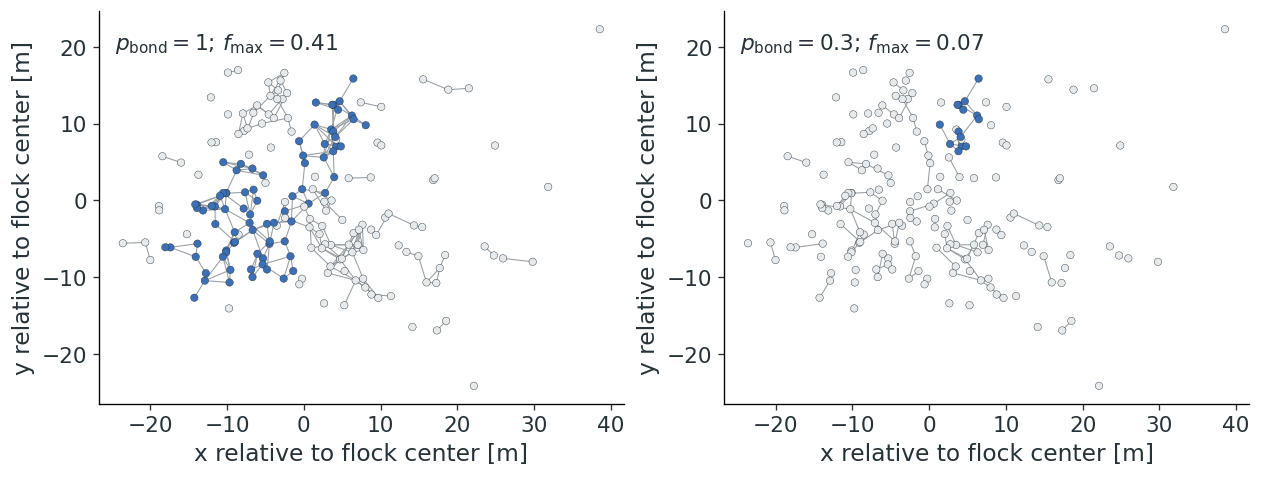

In [72]:
contact_range_m = 4.
possible = bird_distances <= contact_range_m
source, target = bird_pairs[0][possible], bird_pairs[1][possible]
fig, axes = plt.subplots(1, 2, figsize=(10.4, 4.5), layout='constrained')
contact_results = []
for index, (ax, probability) in enumerate(zip(axes, [1., .3])):
    rng = np.random.default_rng(11100+index)
    keep = rng.random(len(source)) < probability
    _, labels = components(bird_count, source[keep], target[keep])
    sizes = np.bincount(labels); largest = labels == sizes.argmax()
    for u, v in zip(source[keep], target[keep]): ax.plot(xy[[u, v], 0], xy[[u, v], 1], color=GREY, lw=.65, zorder=1)
    ax.scatter(*xy.T, s=20, c=np.where(largest, BLUE, LIGHT), edgecolor=INK, linewidth=.25, zorder=2)
    fraction = sizes.max()/bird_count; contact_results.append((probability, fraction))
    ax.set(xlabel='x relative to flock center [m]', ylabel='y relative to flock center [m]', aspect='equal')
    ax.text(.03, .95, fr'$p_{{\mathrm{{bond}}}}={probability:g}$; $f_{{\max}}={fraction:.2f}$',
        transform=ax.transAxes, va='top', bbox={'facecolor':'white', 'edgecolor':'none', 'alpha':.9})
plt.show()

## As we connect nodes, at some point we connect the whole group.

We will look at connections on a square lattice (easier than the random bird perturbations).

- **Site percolation:** Each site survives with probability $p_{\mathrm{occ}}$; surviving neighbors connect.

- **Bond percolation:** Keep all sites; each neighbor link survives with probability $p_{\mathrm{bond}}$.


As $p$ increases, small clusters join together in both cases. 

A cluster **spans** the group when one connected path reaches from the left edge to the right edge.

$f_{\max}=S_{\max}/L^2$: the fraction of all lattice sites in the largest cluster.


In [73]:
def open_edges(side):
    sites = np.arange(side*side).reshape(side,side)
    return (np.concatenate([sites[:,:-1].ravel(),sites[:-1,:].ravel()]),
            np.concatenate([sites[:,1:].ravel(),sites[1:,:].ravel()]))

def percolation_sample(side, probability, rng, mode='site'):
    if mode == 'site':
        occupied = rng.random((side,side)) < probability
        labels, count = ndimage.label(occupied, structure=np.array([[0,1,0],[1,1,1],[0,1,0]]))
        counts = np.bincount(labels.ravel(), minlength=count+1)
        counts[0] = 0
        left = set(labels[:,0]) - {0}; right = set(labels[:,-1]) - {0}
        spanning = bool(left & right)
        fraction = counts.max()/side**2
        return labels, fraction, spanning, None
    a,b = open_edges(side)
    keep = rng.random(len(a)) < probability
    count, labels = components(side*side,a[keep],b[keep])
    labels = labels.reshape(side,side)+1
    counts = np.bincount(labels.ravel()); counts[0]=0
    spanning = bool(set(labels[:,0]) & set(labels[:,-1]))
    return labels, counts.max()/side**2, spanning, (a[keep],b[keep])


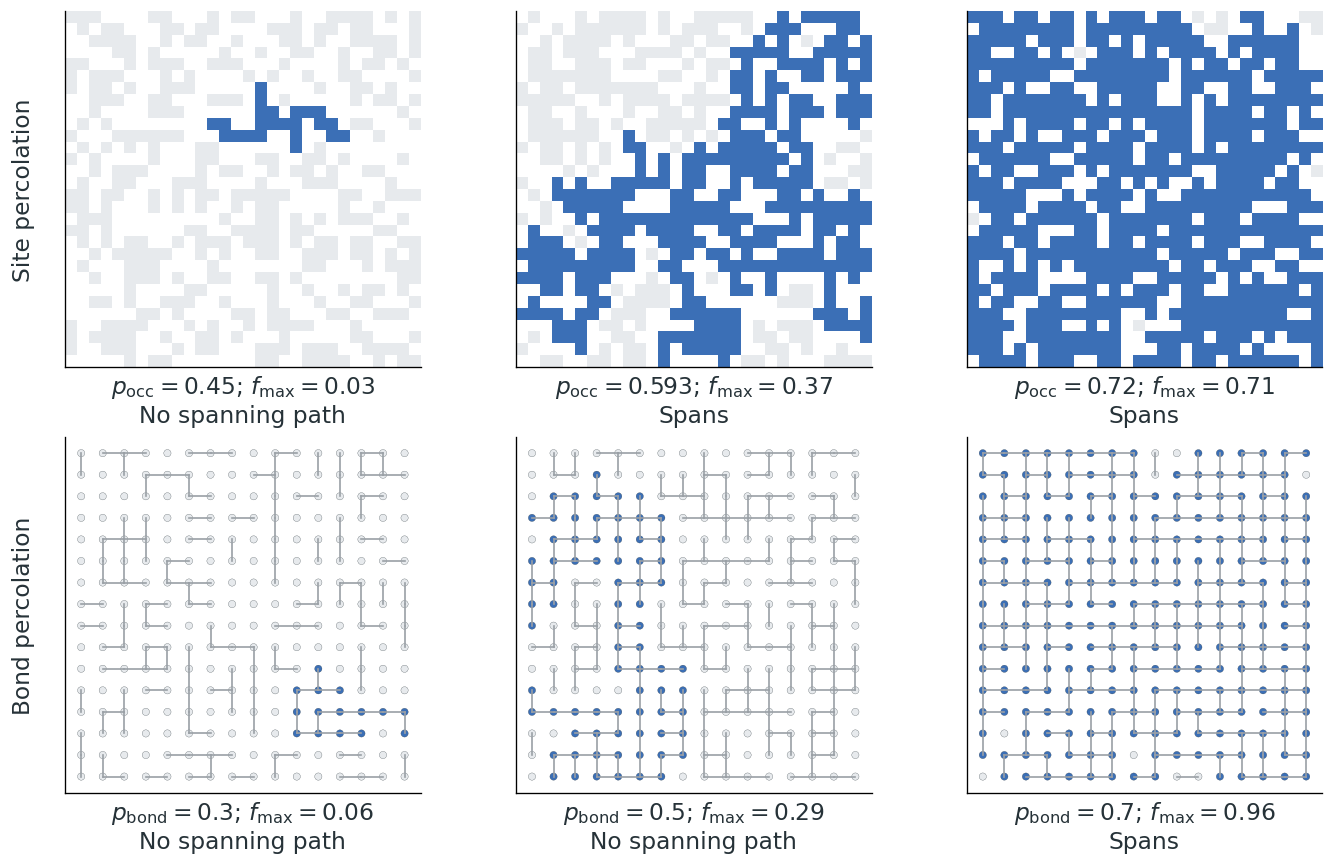

In [74]:
fig, axes = plt.subplots(2, 3, figsize=(11.4, 7.1), layout='constrained')
for row, (mode, probabilities) in enumerate([('site', [.45, .593, .72]), ('bond', [.3, .5, .7])]):
    side = 30 if mode == 'site' else 16
    for column, p in enumerate(probabilities):
        ax = axes[row, column]
        labels, fraction, spans, bonds = percolation_sample(side, p, np.random.default_rng(11400+row*100+column), mode)
        sizes = np.bincount(labels.ravel()); sizes[0] = 0
        largest = (labels == sizes.argmax()) & (labels > 0)
        colors = np.where(labels == 0, 0, np.where(largest, 2, 1))
        cmap = ListedColormap(['white', LIGHT, BLUE])
        if mode == 'site':
            ax.imshow(colors, cmap=cmap, vmin=0, vmax=2, origin='lower', interpolation='nearest')
        else:
            a, b = bonds
            for u, v in zip(a, b): ax.plot([u%side, v%side], [u//side, v//side], color=GREY, lw=1)
            yy, xx = np.indices((side, side))
            ax.scatter(xx.ravel(), yy.ravel(), c=colors.ravel(), cmap=cmap, vmin=0, vmax=2, s=19, edgecolor=INK, linewidth=.15)
            ax.set_aspect('equal')
        ax.set_xticks([]); ax.set_yticks([])
        if column == 0:
            ax.set_ylabel('Site percolation' if mode == 'site' else 'Bond percolation', labelpad=18)
        symbol = r'p_{\mathrm{occ}}' if mode == 'site' else r'p_{\mathrm{bond}}'
        ax.set_xlabel(fr'${symbol}={p:g}$; $f_{{\max}}={fraction:.2f}$'+'\n'+('Spans' if spans else 'No spanning path'))
plt.show()

### The probability of spanning rises as we add sites or bonds


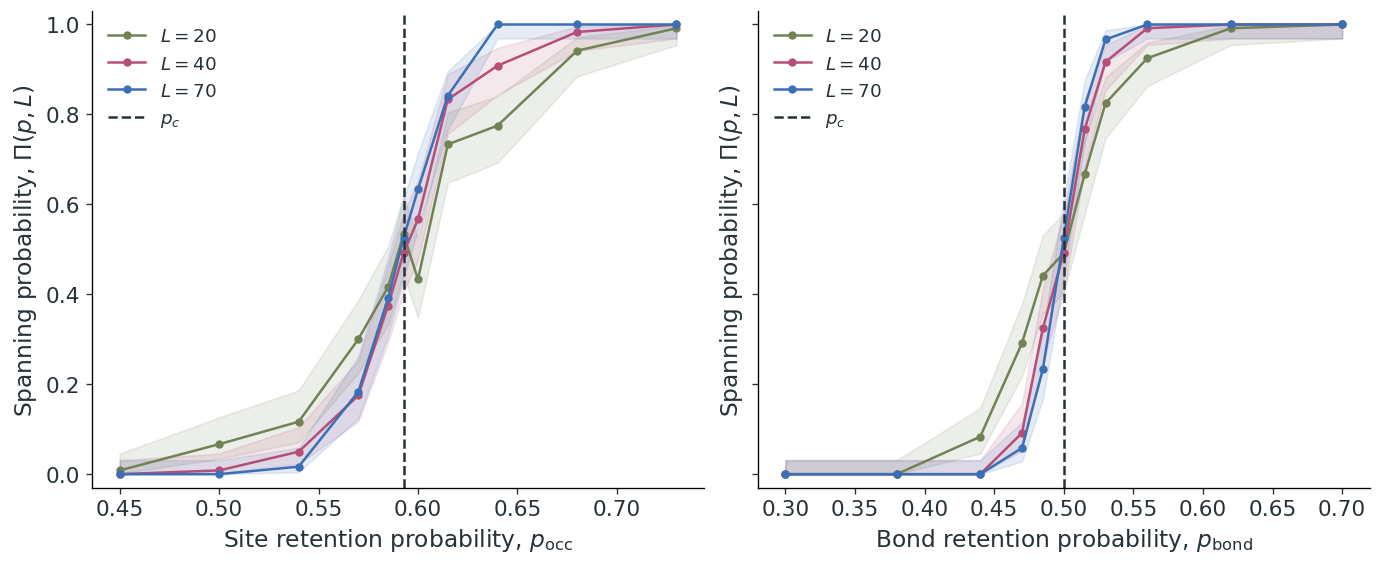

In [75]:
def wilson_interval(successes, trials, z=1.96):
    p = successes/trials
    denominator = 1+z*z/trials
    center = (p+z*z/(2*trials))/denominator
    half = z*np.sqrt(p*(1-p)/trials+z*z/(4*trials**2))/denominator
    return center-half, center+half

percolation_records = []; trials = 120
for mode, probabilities in [('site', [.45, .50, .54, .57, .585, .592746, .60, .615, .64, .68, .73]),
                            ('bond', [.30, .38, .44, .47, .485, .50, .515, .53, .56, .62, .70])]:
    for si, side in enumerate([20, 40, 70]):
        for pi, p in enumerate(probabilities):
            rng = np.random.default_rng(12000+(mode=='bond')*500+si*30+pi)
            successes = 0; fractions = []
            for _ in range(trials):
                _, fraction, spans, _ = percolation_sample(side, p, rng, mode)
                successes += int(spans); fractions.append(fraction)
            low, high = wilson_interval(successes, trials)
            percolation_records.append(dict(mode=mode, L=side, p=p, span=successes/trials,
                low=low, high=high, largest=np.mean(fractions)))
percolation = pd.DataFrame(percolation_records)
fig, axes = plt.subplots(1, 2, figsize=(11.4, 4.6), layout='constrained', sharey=True)
for ax, mode, threshold in zip(axes, ['site', 'bond'], [.592746, .5]):
    for side, color in zip([20, 40, 70], [OLIVE, PINK, BLUE]):
        rows = percolation[(percolation['mode'] == mode) & (percolation.L == side)]
        ax.plot(rows.p, rows.span, 'o-', ms=4, color=color, label=fr'$L={side}$')
        ax.fill_between(rows.p, rows.low, rows.high, color=color, alpha=.13)
    ax.axvline(threshold, color=INK, ls='--', lw=1.5, label=r'$p_c$')
    symbol = r'p_{\mathrm{occ}}' if mode == 'site' else r'p_{\mathrm{bond}}'
    ax.set(xlabel=fr'{mode.capitalize()} retention probability, ${symbol}$', ylabel=r'Spanning probability, $\Pi(p,L)$', ylim=(-.03, 1.03))
    ax.legend(frameon=False)
plt.show()

### Where does spanning begin?


- With few bonds, we get small clusters. As we keep more bonds, paths can cross the lattice.

- The spanning-probability curve rises more sharply for larger lattices. 

- On an infinite square lattice, the bond threshold is exactly $p_c^{\mathrm{bond}}=1/2$.

- For site percolation, the threshold is higher: $p_c^{\mathrm{site}}\simeq0.59$.


## Sources

- S. L. Veatch et al. (2008). *Critical fluctuations in plasma membrane vesicles*. ACS Chemical Biology **3**, 287–293. [Article](https://doi.org/10.1021/cb800012x); [Movie S1](https://doi.org/10.1021/cb800012x.s001).
- T. T. Wu et al. (1976). *Spin-spin correlation functions for the two-dimensional Ising model: exact theory in the scaling region*. Physical Review B **13**, 316–374. [Article](https://doi.org/10.1103/PhysRevB.13.316).
- A. R. Honerkamp-Smith et al. (2008). *Line tensions, correlation lengths, and critical exponents in lipid membranes near critical points*. Biophysical Journal **95**, 236–246. [Article](https://doi.org/10.1529/biophysj.107.128421).
- H. Ling et al. (2019). *Collective turns in jackdaw flocks: kinematics and information transfer*. Journal of the Royal Society Interface **16**, 20190450. [Article](https://doi.org/10.1098/rsif.2019.0450); [Data](https://doi.org/10.6084/m9.figshare.10011374).
- H. Ling et al. (2019). *Behavioural plasticity and the transition to order in jackdaw flocks*. Nature Communications **10**, 5174. [Article and Supplementary Movie 1](https://doi.org/10.1038/s41467-019-13281-4).
- H. Jeckel et al. (2019). *Learning the space-time phase diagram of bacterial swarm expansion*. PNAS **116**, 1489–1494. [Article](https://doi.org/10.1073/pnas.1811722116); [Movie-linked measurements](https://drescherlab.org/data/swarm/).
- A. Cavagna et al. (2010). *Scale-free correlations in starling flocks*. PNAS **107**, 11865–11870. [Article](https://doi.org/10.1073/pnas.1005766107).
- M. E. J. Newman and R. M. Ziff (2000). *Efficient Monte Carlo algorithm and high-precision results for percolation*. Physical Review Letters **85**, 4104–4107. [Article](https://doi.org/10.1103/PhysRevLett.85.4104).
- H. Kesten (1980). *The critical probability of bond percolation on the square lattice equals 1/2*. Communications in Mathematical Physics **74**, 41–59. [Article](https://doi.org/10.1007/BF01197577).